In [ ]:
from dolfinx import fem, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from mpi4py import MPI
import ufl
import numpy as np
from dolfinx.io import gmshio
from dolfinx.fem import locate_dofs_topological
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from scipy.optimize import minimize, approx_fprime
import glob
from scipy.optimize import minimize
import pandas as pd
from scipy.interpolate import griddata
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression
from scipy.interpolate import Rbf
import time

# Solving Full Order Model - Plate with a hole at the center


In [2]:
def FEM_sol(G,K):

    # Define a function space
    V = fem.functionspace(domain,("Lagrange",1,(3,)))

    # Define the Dirichlet Boundary Conditions
    fdim = domain.topology.dim - 1    #(2-1 = 1)
    domain.topology.create_connectivity(fdim,domain.topology.dim)   #connects 1d boundaries to surfaces

    """Since the boundary is clamped at one end we will not have any displacements on one end so locating the facet tag 3 and applying 
    boundary conditions"""

    b_D = locate_dofs_topological(V,fdim,facet_tags.find(3))
    u_D = np.array([0,0,0],dtype = default_scalar_type)
    bc_D = fem.dirichletbc(u_D,b_D,V)

    # Define the Neumann Boundary Conditions, i.e. Constant traction on the right hand side of the geometry

    T_neuman = fem.Constant(domain, default_scalar_type((106.26e6,0,0)))
    ds = ufl.Measure("ds",domain=domain,subdomain_data=facet_tags)

    # Define the weak form of our problem
    def epsilon(u):
        return ufl.sym(ufl.grad(u))
    
    def sigma(u):
        return  (-2/3 * G + K) * ufl.nabla_div(u) * ufl.Identity(len(u)) + 2 * G * epsilon(u)

    # Define the test and the trial function
    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    # Apply the Neumann Boundary Conditions at facet 4
    f = fem.Constant(domain,default_scalar_type((0,0,0)))
    a = ufl.inner(sigma(u),epsilon(v)) * ufl.dx                             #stiffness matrix
    L = ufl.dot(f, v) * ufl.dx + ufl.dot(T_neuman, v) * ds(4)               # force vector
    

    # Create Solver Linear
    problem = LinearProblem(a,L,bcs=[bc_D],petsc_options={"ksp_type": "preonly", "pc_type": "lu"})
    #print(f"Size of stiffness matrix: {problem.A.size}")  # PETSc matrix size
    #print(f"Size of force vector: {problem.b.size}")  # PETSc vector size
    uh = problem.solve()
    #print(f"uh shape: {np.shape(uh)}")

    # Post Processing for retreving the solution only in the experimental dataset domain
    x_origin_sub = [20e-3, 100e-3]
    y_origin_sub = 10e-3

    domain_arr = domain.geometry.x
    #print(f"domain_array shape: {np.shape(domain_arr)}")
    #print(f"domain_array: {domain_arr}")

    
    


    # Extract x-coordinates and apply condition
    subdomain_condition = (domain_arr[:, 0] >= x_origin_sub[0]) & (domain_arr[:, 0] <= x_origin_sub[1]) 
    #print(f"subdomain_condition: {subdomain_condition}")
    num_dofs = V.dofmap.index_map.size_local
    
    uh_arr = uh.x.array[:].reshape((num_dofs, -1))
    #print(f"uh_arr shape: {np.shape(uh_arr)}")


    # Extract the local DOF indices for the subdomain
    subdomain_dofs = np.where(subdomain_condition)[0]
    subdomain_dofs = np.array(subdomain_dofs, dtype= np.int32)

    # Extract the local submatrix and subvector
    #A_sub = problem.A[subdomain_dofs, :][:, subdomain_dofs]  # Stiffness matrix for the subdomain
    #b_sub = problem.b[subdomain_dofs]  # Force vector for the subdomain
    
    # Print the size of the submatrix and subvector
    #print(f"Size of stiffness matrix for subdomain: {np.shape(A_sub)}")
    #print(f"Size of force vector for subdomain: {np.shape(b_sub)}")

    # Get the subdomain for using with the data
    domain_sub = domain_arr[subdomain_condition]
    #print(f"domain_sub shape: {np.shape(domain_sub)}")   #shape: (7536 X 3)
    #print(f"domain sub before: {domain_sub}")
    #print("\n****************\n")
    domain_sub[:, 0] -= x_origin_sub[0]
    domain_sub[:, 1] += y_origin_sub
    u_sub = uh_arr[subdomain_condition]
    #u_vec = u_sub[:, 0:2][0] 
    #print(f"u_sub shape: {np.shape(u_sub)}")
    #print(f"u_vec shape: {np.shape(u_vec)}")
    #print(f"u_vec: \n", u_vec)
    #print(f"Domain sub after: {domain_sub}")
    
    #print(f"U_sub: {u_sub}")


    return domain, uh, domain_sub, u_sub
if __name__ == "__main__":
    domain,cell_tags,facet_tags = gmshio.read_from_msh('tensile_test_specimen.msh', MPI.COMM_WORLD, 0)
    #domain, uh, domain_sub, u_sub = FEM_sol(G= 70e9,K = 120e9)

Info    : Reading 'tensile_test_specimen.msh'...
Info    : 26 entities
Info    : 9753 nodes
Info    : 19100 elements
Info    : Done reading 'tensile_test_specimen.msh'


Inverse FOM - Change to cell to run

if __name__ == "__main__":
    domain,cell_tags,facet_tags = gmshio.read_from_msh('tensile_test_specimen.msh', MPI.COMM_WORLD, 0)
    X,Y,Z_x,Z_y = Interpolate_exp()
    train_ds = np.hstack((X.reshape(X.shape[0], 1), Y.reshape(Y.shape[0], 1), Z_x.reshape(Z_x.shape[0], 1), Z_y.reshape(Z_y.shape[0], 1)))
    beta = [50e9, 50e9]
    #counter = 0
    result = minimize(
    fun=lambda x: mse_loss(domain, facet_tags, train_ds, x),
    x0=beta,
    method='Nelder-Mead',
    options={'gtol': 1e-15, 'maxiter': 100}
    )
    total_end_time = time.time()
    total_elapsed_time = total_end_time - total_start_time
    G_sol,K_sol = result.x
    print(f"Final value for Shear Modulus is {G_sol:.2e} & Final value of Bulk Modulus is {K_sol:.2e}")
    print(f"Total number of iterations before convergence was achieved: {result.nit}")
    print(f"\nTotal Optimization Time: {total_elapsed_time:.6f} seconds")
    print(f"Total Iterations: {iteration_count}")
    #print(f"time elapsed: {elapsed_time}")
    #print(f"Iteratiosn done: {iteration_count}")



    domain_sol, deformation_sol, subdomain_sol, deformation_sub_sol = FEM_sol(G_sol,K_sol)
    df_solution = pd.DataFrame({"x": subdomain_sol[:, 0], "y": subdomain_sol[:, 1], "z_x": deformation_sub_sol[:, 0], "z_y": deformation_sub_sol[:, 1]})


    
    displacement_field(df_solution)
    absolute_error(subdomain_sol,deformation_sub_sol,df_solution,X,Y,Z_x,Z_y)


# Generating FOM training data for Proper Orthogonal Decomposition

In [ ]:
import os
def generate_training_data():
    G_values = np.linspace(50e9, 140e9, 900)
    K_values = np.linspace(50e9, 140e9, 900)
    save_folder = "FOM_displacement_data"
    _, _, domain_sub, _ = FEM_sol(G_values[0], K_values[0])
    os.makedirs(save_folder, exist_ok=True)
    for G, K in zip(G_values, K_values):
        print(f"Running FEM for G={G} and K={K}")
        _, _, _, u_sub = FEM_sol(G, K)
        #filename = f"full_domain_data_G_{G/1e9:.3f}_K_{K/1e9:.3f}.csv"
        filename = os.path.join(save_folder, f"full_domain_data_G_{G:.4f}_K_{K:.4f}.csv")
        sampled_data = np.column_stack((domain_sub[:, 0], domain_sub[:, 1], u_sub[:, 0], u_sub[:, 1]))     #all dimensionare in in meters
        df_sampled = pd.DataFrame(sampled_data, columns=["x", "y","ux", "uy"])
        df_sampled. to_csv(filename, index=False)
        print(f"Saved data for G={G}, K={K} to {filename}")

# Generating Snapshot Matrix

In [6]:
def construct_snapshot_matrix():
    # Find all CSV files matching the pattern
    csv_files = sorted(glob.glob("FOM_displacement_data/full_domain_data_G_*.csv"))  # Ensure sorted order
    #csv_files = glob.glob("full_domain_data_G_*.csv")

    snapshots = []  # To store each column vector

    for file in csv_files:
        df = pd.read_csv(file)
        
        # Extract u_x and u_y
        u_x = df["ux"].values  # Shape: (7536,)
        u_y = df["uy"].values  # Shape: (7536,)

        # Stack u_x and u_y vertically and store as one column
        snapshot_column = np.vstack((u_x, u_y))  # Shape: (15072,)

        # Reshape to (15072, 1) to allow correct stacking
        snapshot_column = snapshot_column.reshape(-1, 1)

        snapshots.append(snapshot_column)  # Append to snapshot list

    # Convert list to 2D NumPy array (15072 x 100)
    S= np.column_stack(snapshots)
    
    print(f"Snapshot matrix shape: {S.shape}")  # SIZE: (15072 x 100)

    # Save to CSV
    np.savetxt("snapshot_matrix_columnstacked.csv", S, delimiter=",")
    print("Snapshot matrix saved as snapshot_matrixcolumnstacked.csv")

    return S

In [7]:
S = construct_snapshot_matrix()

Snapshot matrix shape: (15072, 900)
Snapshot matrix saved as snapshot_matrixcolumnstacked.csv


# Applying SVD on the generated snapshot matrix


In [134]:
def compute_svd(snapshot_file="snapshot_matrix_columnstacked.csv", energy_threshold=0.50):
    # Load snapshot matrix
    U_scaled = np.loadtxt(snapshot_file, delimiter=",")
    print(f"U_scaled shape: {np.shape(U_scaled)}")  #(15072 x 50)
    
    # Perform SVD
    U, S, Vt = np.linalg.svd(U_scaled, full_matrices=False)
    print(f"U shape: {np.shape(U)}")  #(15072 x 50)
    print(f"S shape: {np.shape(S)}")   #(50 x 50)
    #print(f"S Matrix: \n: {S}")
    print(f"Vt shape: {np.shape(Vt)}") #(50 x 50) 

    # Compute energy capture
    singular_values_squared = S**2
    total_energy = np.sum(singular_values_squared)
    cumulative_energy = np.cumsum(singular_values_squared) / total_energy

    # Select the first K basis vectors that capture the required energy
    #K = np.argmax(cumulative_energy >= energy_threshold) + 1  # Find first index where energy ≥ 99%
    #print(f"Number of basis vectors (K) selected: {K}")

    # Extract first K basis vectors
    U_reduced = U[:, :8]  
    print(f"Shape of U red: {np.shape(U_reduced)}") #(7536 x 8)
    

    # Save results
    np.savetxt("reduced_basis_U_for_columnstacked.csv", U_reduced, delimiter=",")


    return U_reduced

In [135]:
U_reduced = compute_svd(snapshot_file="snapshot_matrix_columnstacked.csv", energy_threshold=0.50)

U_scaled shape: (15072, 900)
U shape: (15072, 900)
S shape: (900,)
Vt shape: (900, 900)
Shape of U red: (15072, 8)


# Computing POD coefficient - Function

In [102]:
# Load the dominant mode (15072 x 8)
dominant_mode = np.loadtxt("reduced_basis_U_for_columnstacked.csv", delimiter= ",")  # Ensure it's a column vector 7536 x 8
#dominant_mode = dominant_mode.reshape(-1,1) 
print(f"Size of Dominant Mode: {np.shape(dominant_mode)}")

def compute_pod_coefficient(displacement_file):
    # Load displacement data from CSV
    df = pd.read_csv(displacement_file)
    
    # Extract displacement values (ux, uy) and stack them vertically
    x = df['x'].values.reshape(-1, 1)  # (7536, 1)
    y = df['y'].values.reshape(-1, 1)  # (7536, 1)
    ux = df['ux'].values.reshape(-1, 1)  # (7536, 1)
    uy = df['uy'].values.reshape(-1, 1)  # (7536, 1)
    displacement = np.vstack((ux, uy)).reshape(-1,1)   # (15072,1)
    
    # Compute POD coefficient a = (dominant_mode^T * displacement)
    a = np.dot(dominant_mode.T, displacement)  # 8 x 1
    #print(f"a shape: {np.shape(a)}")
    
    # Reconstruct approximate displacement field
    approx_displacement = dominant_mode @ a  # 15072x1
    
    return a, approx_displacement, x,y

Size of Dominant Mode: (15072, 8)


In [ ]:
# Load multiple displacement fields and corresponding material parameters
displacement_files = glob.glob("FOM_displacement_data/full_domain_data_G_*.csv")  # Adjust path
material_params = []  # Store (G, K)
pod_coeffs = []  # Store computed POD coefficients   (400x 16) Each row contains pod coefficeint of respective FOM data
import re
for file in displacement_files:
    match = re.search(r"G_([\d\.]+)_K_([\d\.]+)", file)
    if match:
        G_str, K_str = match.groups() # Extract G and K correctly
        G = float(G_str.rstrip('.'))
        K = float(K_str.rstrip('.')) 
        a, _ = compute_pod_coefficient(file) #8x1
        material_params.append([G, K])
        pod_coeffs.append(a.flatten())
        #print(pod_coeffs)
#print(f"POD Coeff shape: {np.shape(pod_coeffs)}")
#print(f"material_params shape: {np.shape(material_params)}")
#print(material_params)
#print(pod_coeffs)

POD Coeff shape: (900, 8)
material_params shape: (900, 2)
[[103559510567.297, 103559510567.297], [127986651835.3726, 127986651835.3726], [101357063403.782, 101357063403.782], [138798665183.5373, 138798665183.5373], [131890989988.8765, 131890989988.8765], [97953281423.8042, 97953281423.8042], [114071190211.3459, 114071190211.3459], [111268075639.5995, 111268075639.5995], [60611790878.7542, 60611790878.7542], [72224694104.5606, 72224694104.5606], [57408231368.1869, 57408231368.1869], [103159065628.4761, 103159065628.4761], [63414905450.5006, 63414905450.5006], [101857619577.3081, 101857619577.3081], [119377085650.723, 119377085650.723], [115773081201.3348, 115773081201.3348], [113270300333.7041, 113270300333.7041], [78231368186.8743, 78231368186.8743], [138398220244.7164, 138398220244.7164], [74226918798.6652, 74226918798.6652], [107664071190.2113, 107664071190.2113], [58209121245.8287, 58209121245.8287], [100055617352.614, 100055617352.614], [71624026696.3293, 71624026696.3293], [670189

# Training Radial Basis Function (RBF) Kernel to predict POD coefficents

In [ ]:

# Convert to numpy arrays
X_train = np.array(material_params)  # (600,2) -> G, K values
Y_train = np.array(pod_coeffs)  # (600,8)
# Separate G and K values
G_train, K_train = X_train[:, 0], X_train[:, 1]

# Train an RBF model for each POD coefficient separately
rbf_models = [Rbf(G_train, K_train, Y_train[:, i], function='multiquadric', epsilon=10.0) for i in range(8)]

# Prediction function
def predict_pod_coeff_rbf(G, K):
    return np.array([rbf(G, K) for rbf in rbf_models]).reshape(8,1)

# Example
#predicted_coeffs = predict_pod_coeff_rbf(50, 75)
#print(predicted_coeffs)

# Extrapolate experimental displacements on the FOM generated FEM gird

#### This is done to compare the said extrapolated displacements with Reduced Order Model (ROM) obtained approximate displacement field

In [90]:
def Interpolate_exp_rom():

    df2 = pd.read_csv('reference_fem_data_G_70000000000.0_K_120000000000.0.csv')
    node_coordinates = df2[['x','y']].values
    #_,_,node_coordinates,_,_,_ = FEM_sol(82e9, 120e9)
    print("**********\n")
    print(f"node_coordinates shape: {np.shape(node_coordinates)}")
    df = pd.read_csv('20231116_displacements_interpolated.csv')
    center_x, center_y = 40e-3, 10e-3
    radius = 4e-3

    def remove_outliers(df,columns,threshold=3):
        cleaned_df = df.copy()
        for column in columns:
            mean = cleaned_df[column].mean()
            std = cleaned_df[column].std()

            z_score = (cleaned_df[column] - mean)/std
            cleaned_df = cleaned_df[np.abs(z_score) <= threshold]
        return cleaned_df
    
    def mask_hole(X,Y):

        # Calculate the distance of each point from the center of the circle
        distance_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)

        # Create a mask: True for points outside the circle, False for points inside
        return distance_from_center >= radius

    def get_displacement_at_point(df,x,y,isClearOutlier):

        if isClearOutlier:
            df = remove_outliers(df,['ux','uy'],3)

            # Extracting points and displacements from the dataframe
            points = df[['x','y']].values/1000
            displacement_x = df['ux'].values/1000
            displacement_y = df['uy'].values/1000

            # Create Interpolators for displacement_x and displacement_y
            interp_x = np.nan_to_num(griddata(points,displacement_x,(x,y),method="linear"),nan=0.0)
            interp_y = np.nan_to_num(griddata(points,displacement_y,(x,y),method="linear"),nan=0.0)

        return interp_x, interp_y

    X,Y = node_coordinates[:,0], node_coordinates[:,1]
    mask = mask_hole(X,Y)
    u_x, u_y = get_displacement_at_point(df,X,Y,True)
    print(f"u_x shape: {np.shape(u_x)}")
    X_masked = X[mask]
    Y_masked = Y[mask]
    u_x_masked = u_x[mask]
    u_y_masked = u_y[mask]
    print(f"X_masked shape: {np.shape(X_masked)}")
    print(f"ux_masked shape: {np.shape(u_x_masked)}")

    # Plotting the mesh
    fig, ax = plt.subplots(2, 1, figsize=(25, 15))

    # Subplot for displacement_x
    contour_x = ax[0].tricontourf(X_masked, Y_masked , u_x_masked, levels=100, cmap='turbo')
    cbar_x = fig.colorbar(contour_x, ax=ax[0])
    cbar_x.set_label(label='Displacement X (m)', size='18')
    cbar_x.ax.tick_params(labelsize=18)
    ax[0].set_title('Experimental X Displacement',size='20')
    ax[0].set_xlabel('X Coordinate [m]',size='18')
    ax[0].set_ylabel('Y Coordinate [m]', size='18')
    ax[0].tick_params(axis='both', which='major', labelsize=18)
    ax[0].grid(True)

    # Adding the hole to the geometry
    theta = np.linspace(0,2*np.pi,100)
    circle_x = center_x + radius * np.cos(theta)
    circle_y = center_y + radius * np.sin(theta)
    ax[0].fill(circle_x,circle_y,'w-',lw=2)

    # Subplot for Y displacement
    contour_y = ax[1].tricontourf(X_masked, Y_masked , u_y_masked, levels=100, cmap='turbo')
    cbar_y = fig.colorbar(contour_y, ax=ax[1])
    cbar_y.set_label(label='Displacement Y (m)', size='18')
    cbar_y.ax.tick_params(labelsize=18)
    ax[1].set_title('Experimental Y Displacement', size='20')
    ax[1].set_xlabel('X Coordinate [m]', size='18')
    ax[1].set_ylabel('Y Coordinate [m]', size='18')
    ax[1].tick_params(axis='both', which='major', labelsize=18)
    ax[1].grid(True)

    ax[1].fill(circle_x,circle_y,'w-',lw=2)
#/root/11257192/output_diagram/
    #plt.tight_layout()
    #plt.savefig('experimental_displacement.pdf',format="pdf")
    return X,Y,u_x,u_y


In [ ]:
_,_, ux_exp_interp, uy_exp_interp = Interpolate_exp_rom()  #returns u_x and u_y experimental displacements extrapolated on fem grid

In [19]:
u_exp = np.hstack((ux_exp_interp.reshape(-1,1), uy_exp_interp.reshape(-1,1)))

print(f"u_exp shape: {np.shape(u_exp)}")

u_exp shape: (7536, 2)


# Defining Loss Function 
### Later inverse problem is formulated based on ROM Model to get Material Parameters, thus bypassing the expensive Full Order Model

In [ ]:


# Loss function definition with normalized displacements
loss_func = []
G_loss = []
K_loss = []


iteration_count = 0  # Global counter for iterations
total_start_time = time.time() 
def loss_function(params, u_exp, mean_x, std_x, mean_y, std_y):
    global iteration_count
    iteration_count += 1
    
    G, K = params
    predicted_a = predict_pod_coeff_rbf(G, K)
    #predicted_a = predicted_a.reshape(-1,1)

    # Compute ROM displacement (15072 x 1)
    u_rom = dominant_mode @ predicted_a  

    # Normalize FEM (experimental) and ROM displacements
    u_exp_x_norm = (u_exp[:, 0] - mean_x) / std_x
    u_exp_y_norm = (u_exp[:, 1] - mean_y) / std_y
    u_rom_x_norm = (u_rom[:7536, 0] - mean_x) / std_x
    u_rom_y_norm = (u_rom[7536:, 0] - mean_y) / std_y

    # Compute normalized errors
    err_norm_ux = np.linalg.norm(u_exp_x_norm - u_rom_x_norm)
    err_norm_uy = np.linalg.norm(u_exp_y_norm - u_rom_y_norm)

    # Final loss
    result = 0.5 * (err_norm_ux**2 + err_norm_uy**2)
    loss_func.append(result)
    G_loss.append(G)
    K_loss.append(K)
    return result

# Optimization function
def optimize_parameters(u_exp, initial_guess, mean_x, std_x, mean_y, std_y):
    result = minimize(loss_function, initial_guess, args=(u_exp, mean_x, std_x, mean_y, std_y), 
                      method='Nelder-Mead', options={'gtol': 1e-15, 'maxiter': 300})
    return result.x, result.fun

# Experimental displacement data (u_exp)
u_exp = np.hstack((ux_exp_interp.reshape(-1,1), uy_exp_interp.reshape(-1,1)))  # Shape (7536, 2)

# Compute normalization parameters
mean_x, std_x = np.mean(u_exp[:, 0]), np.std(u_exp[:, 0])
mean_y, std_y = np.mean(u_exp[:, 1]), np.std(u_exp[:, 1])

# Initial guess
initial_guess = [60e9, 100e9]

# Optimize material parameters
optimized_params, optimized_loss = optimize_parameters(u_exp, initial_guess, mean_x, std_x, mean_y, std_y)
# Calculate total time after optimization
total_end_time = time.time()
total_elapsed_time = total_end_time - total_start_time

print(f"\nTotal Optimization Time: {total_elapsed_time:.6f} seconds")
print(f"Total Iterations: {iteration_count}")
# Ground truth values
G_true = 71.4e9  
K_true = 94.4e9  

# Optimized values
G_opt, K_opt = optimized_params

# Compute absolute error in percentage
G_error = abs((G_opt - G_true) / G_true) * 100
K_error = abs((K_opt - K_true) / K_true) * 100

# Print results
print("\nErrors:")
print(f"G error: {G_error:.4f} %")
print(f"K error: {K_error:.4f} %")

print("\nOptimized Material Parameters:")
print(f"G: {G_opt:.2e} Pa")
print(f"K: {K_opt:.2e} Pa")
print(f"Optimized Loss: {optimized_loss:.6f}")




## Plotting Full Order Model X and Y displacement

Reference File for G 71400000000.0 and K 92900000000.0 has been created successfully


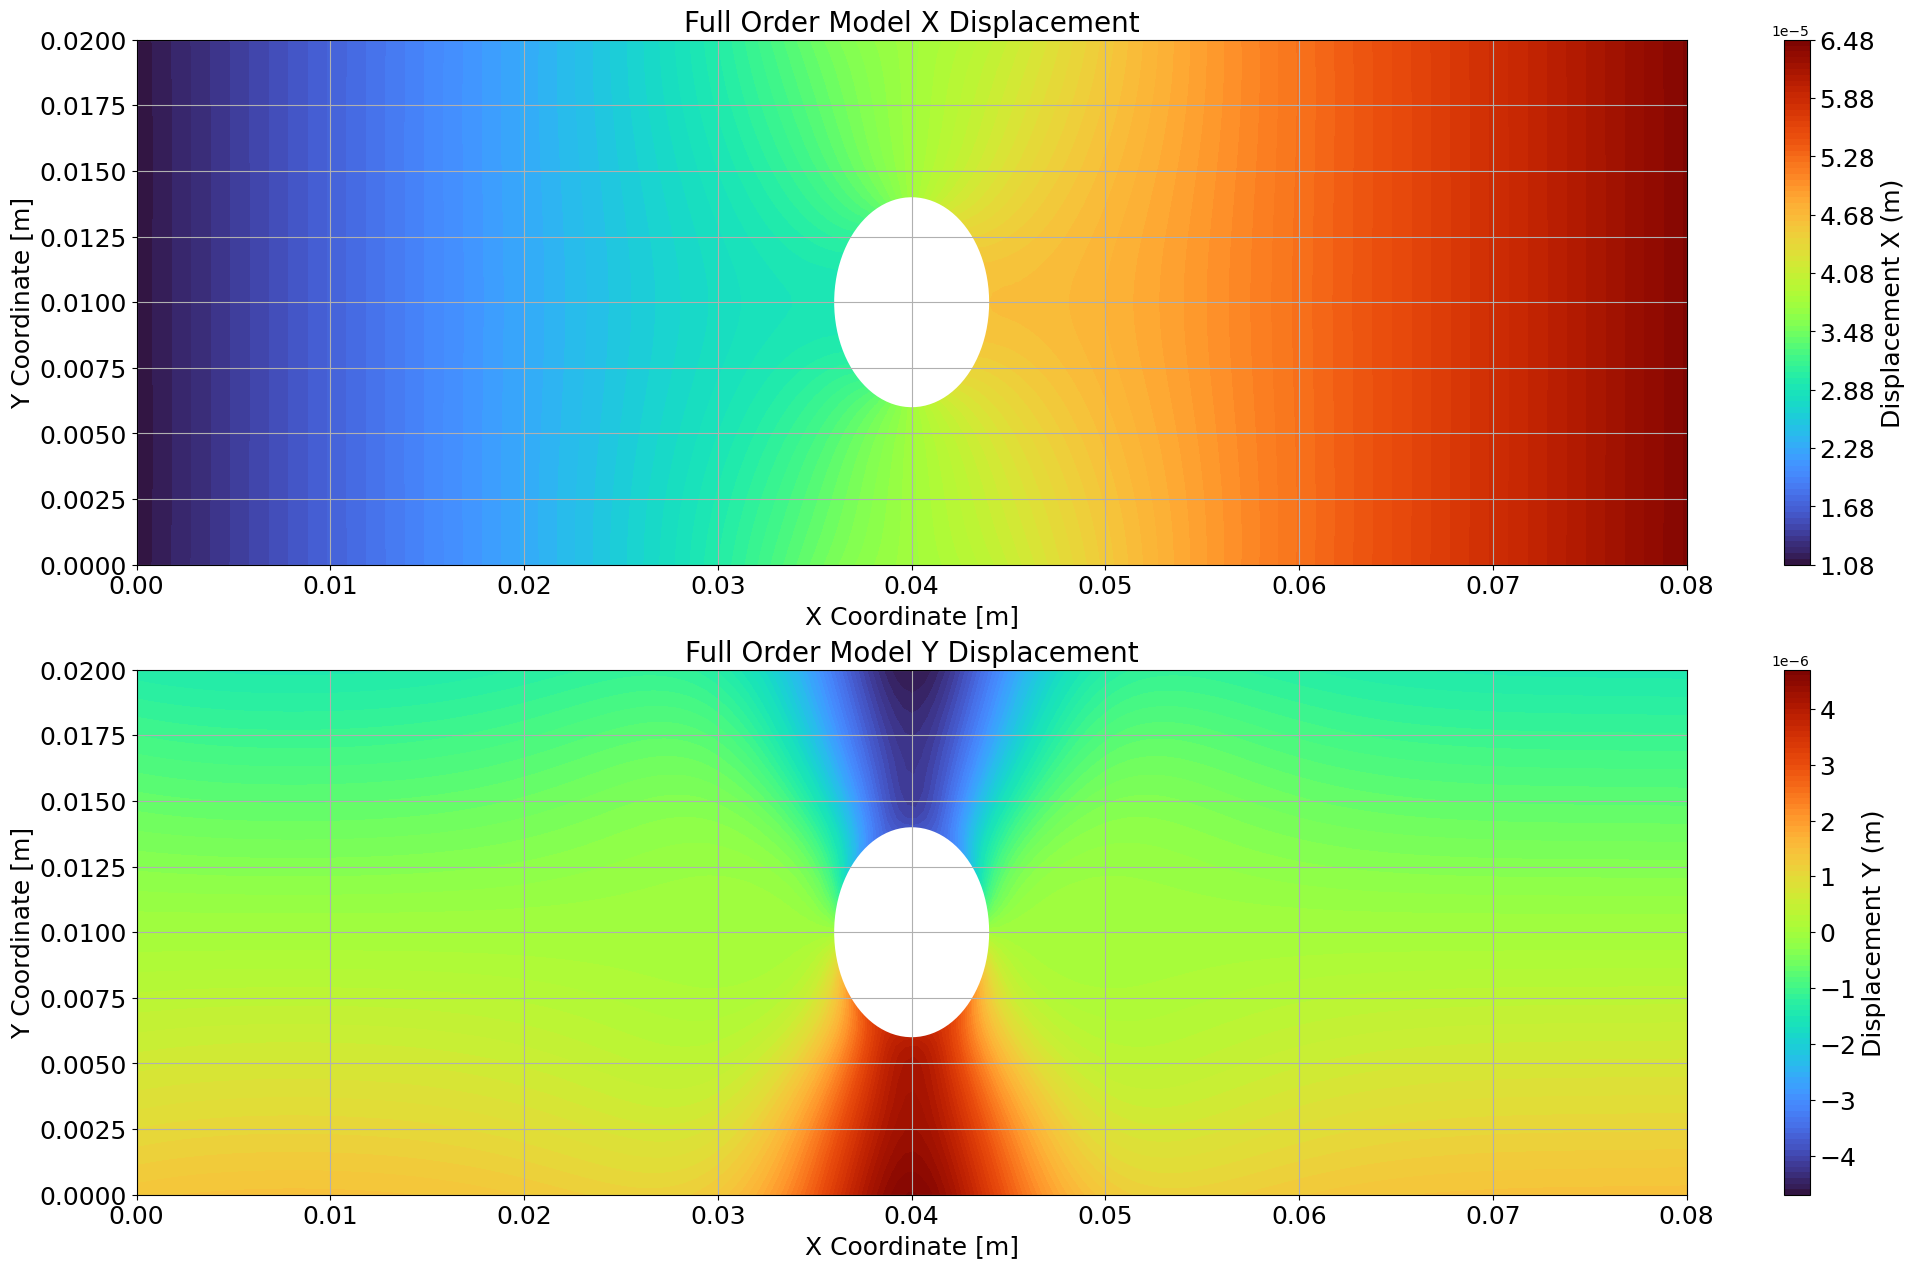

In [100]:
G_FEM, K_FEM = 71.4e9, 92.9e9
_,_,domain_sub, u_sub = FEM_sol(G_FEM, K_FEM)
sampled_data = np.column_stack((domain_sub[:,0], domain_sub[:, 1], u_sub[:,0], u_sub[:,1]))
df_sampled = pd.DataFrame(sampled_data, columns= ["x", "y", "ux", "uy"] )
file_name = f"reference_fem_data_G_{G_FEM}_K_{K_FEM}.csv"
df_sampled.to_csv(file_name, index = False)
print(f"Reference File for G {G_FEM} and K {K_FEM} has been created successfully")


df2 = pd.read_csv(file_name)
#points = df2[['x','y']].values
fem_x = df2[['x']].values
fem_y = df2[['y']].values
fem_x_disp = df2['ux'].values
fem_y_disp = df2['uy'].values

# Plotting the mesh
fig, ax = plt.subplots(2, 1, figsize=(25, 15))
# Subplot for displacement_x
contour_x = ax[0].tricontourf(fem_x.flatten(), fem_y.flatten() , fem_x_disp, levels=100, cmap='turbo')
cbar_x = fig.colorbar(contour_x, ax=ax[0])
cbar_x.set_label(label='Displacement X (m)', size='18')
cbar_x.ax.tick_params(labelsize=18)
ax[0].set_title('Full Order Model X Displacement',size='20')
ax[0].set_xlabel('X Coordinate [m]',size='18')
ax[0].set_ylabel('Y Coordinate [m]', size='18')
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].grid(True)

# Adding the hole to the geometry
center_x, center_y = 40e-3, 10e-3
radius = 4e-3


theta = np.linspace(0,2*np.pi,100)
circle_x = center_x + radius * np.cos(theta)
circle_y = center_y + radius * np.sin(theta)
ax[0].fill(circle_x,circle_y,'w-',lw=2)


# Subplot for Y displacement
contour_y = ax[1].tricontourf(fem_x.flatten(), fem_y.flatten() , fem_y_disp, levels=100, cmap='turbo')
cbar_y = fig.colorbar(contour_y, ax=ax[1])
cbar_y.set_label(label='Displacement Y (m)', size='18')
cbar_y.ax.tick_params(labelsize=18)
ax[1].set_title('Full Order Model Y Displacement', size='20')
ax[1].set_xlabel('X Coordinate [m]', size='18')
ax[1].set_ylabel('Y Coordinate [m]', size='18')
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].grid(True)
ax[1].fill(circle_x,circle_y,'w-',lw=2)


plt.show()


## Plotting Reduced Order Model X and Y displacements

Predicted POD Coefficients: (8, 1)
Approximate Displacement Field Shape: (15072, 1)


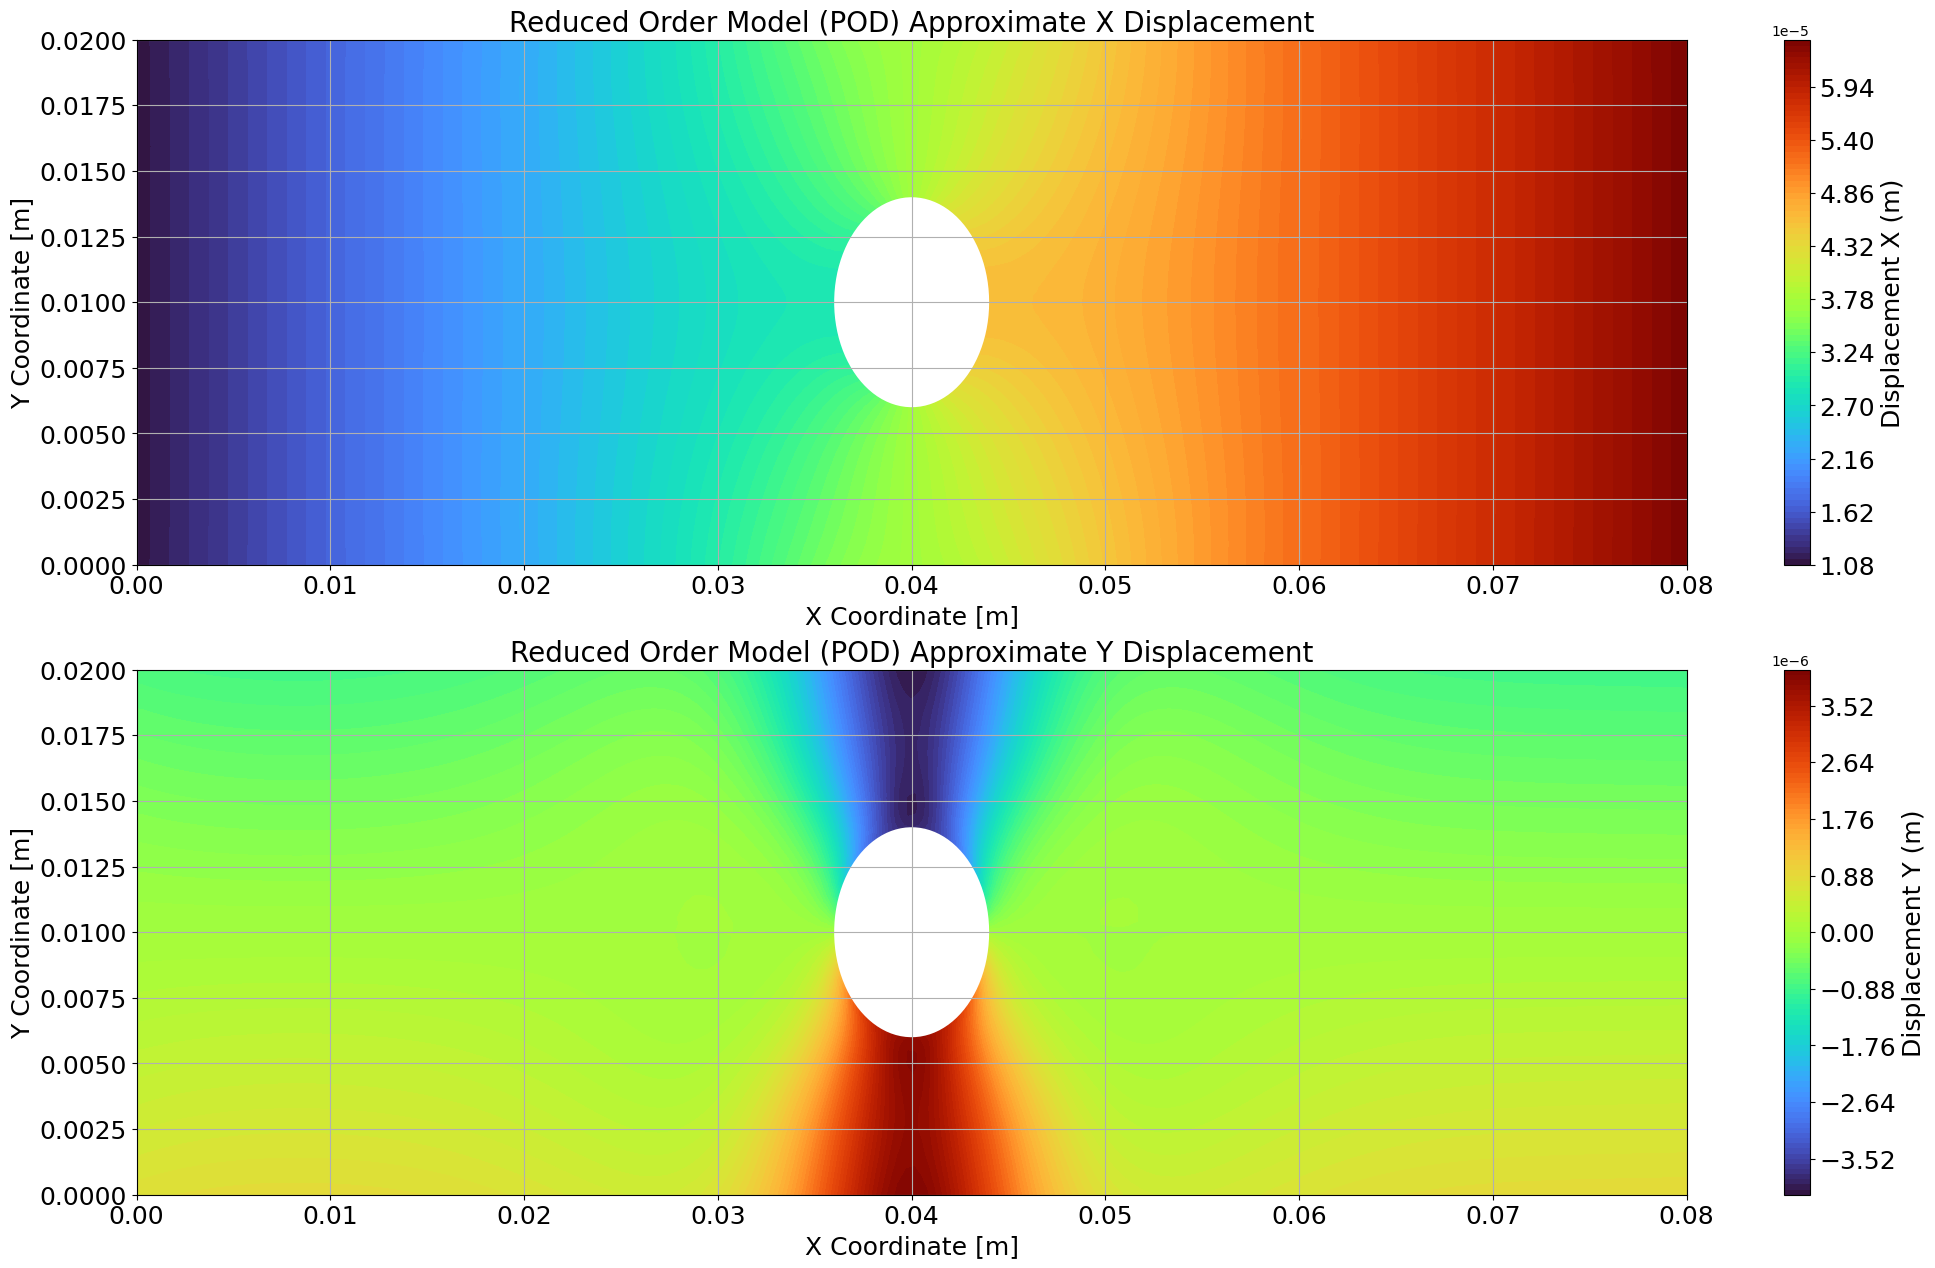

In [ ]:


# Convert to numpy arrays
X = np.array(material_params)  # (100,2) -> G, K values
y = np.array(pod_coeffs)  # (100,16), 8 POD coefficients for ux and uy

# Train regression model
regressor = LinearRegression()
regressor.fit(X, y)  # Now y has correct shape (100,16)

def predict_pod_coefficient(G, K):
    return regressor.predict(np.array([[G, K]]))[0]  # Returns (16,)

# Example usage
G_new, K_new = 73.7e9, 94.8e9  # Replace with actual values
predicted_a = predict_pod_coefficient(G_new, K_new)  # Shape (16,)

# Reshape predicted coefficients into (8,2) for ux and uy
predicted_a = predicted_a.reshape(8, 1)

# Compute approximate displacement
approx_displacement_new = dominant_mode @ predicted_a  # (7536,2)

print("Predicted POD Coefficients:", predicted_a.shape)  # Should be (8,2)
print("Approximate Displacement Field Shape:", approx_displacement_new.shape)  # (7536,2)

# Split approximate displacement into ux and uy
ux_approx = approx_displacement_new[:7536, 0]  # (7536,)
uy_approx = approx_displacement_new[7536:, 0]  # (7536,)

# Load spatial coordinates from one of the files
example_file = displacement_files[0]
_, _, x, y = compute_pod_coefficient(example_file)

center_x, center_y = 40e-3, 10e-3
radius = 4e-3

# Plotting the mesh
fig, ax = plt.subplots(2, 1, figsize=(25, 15))
# Subplot for displacement_x
contour_x = ax[0].tricontourf(x.flatten(), y.flatten() , ux_approx, levels=100, cmap='turbo')
cbar_x = fig.colorbar(contour_x, ax=ax[0])
cbar_x.set_label(label='Displacement X (m)', size='18')
cbar_x.ax.tick_params(labelsize=18)
ax[0].set_title('Reduced Order Model (POD) Approximate X Displacement',size='20')
ax[0].set_xlabel('X Coordinate [m]',size='18')
ax[0].set_ylabel('Y Coordinate [m]', size='18')
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].grid(True)
# Adding the hole to the geometry
theta = np.linspace(0,2*np.pi,100)
circle_x = center_x + radius * np.cos(theta)
circle_y = center_y + radius * np.sin(theta)
ax[0].fill(circle_x,circle_y,'w-',lw=2)
# Subplot for Y displacement
contour_y = ax[1].tricontourf(x.flatten(), y.flatten() , uy_approx, levels=100, cmap='turbo')
cbar_y = fig.colorbar(contour_y, ax=ax[1])
cbar_y.set_label(label='Displacement Y (m)', size='18')
cbar_y.ax.tick_params(labelsize=18)
ax[1].set_title('Reduced Order Model (POD) Approximate Y Displacement', size='20')
ax[1].set_xlabel('X Coordinate [m]', size='18')
ax[1].set_ylabel('Y Coordinate [m]', size='18')
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].grid(True)
ax[1].fill(circle_x,circle_y,'w-',lw=2)


plt.show()


# ERROR Between ROM and FOM


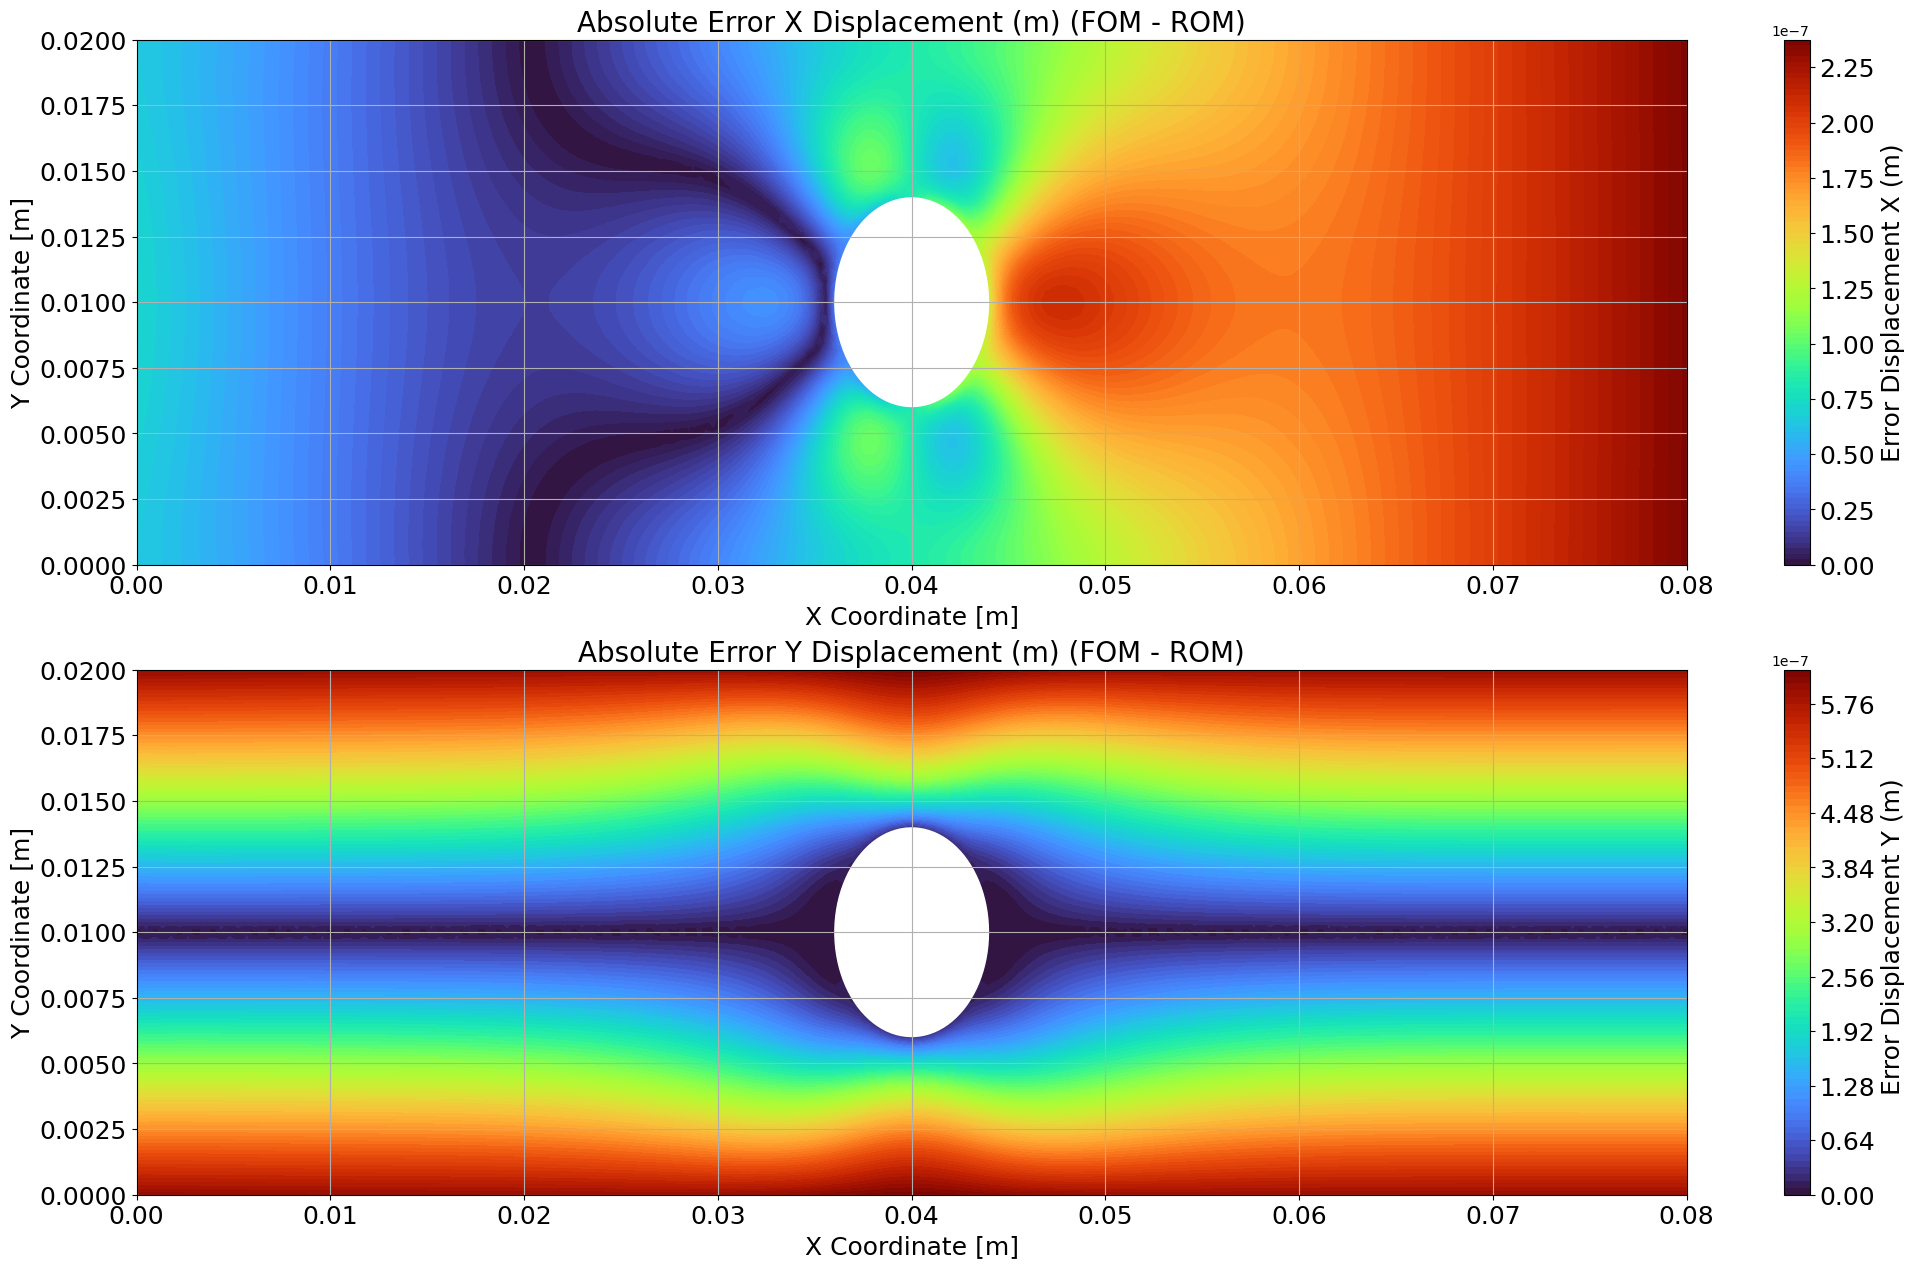

In [111]:

# Compute errors
error_ux = np.abs(fem_x_disp - ux_approx)
error_uy = np.abs(fem_y_disp - uy_approx)

#print(f"Mean Ux error: {np.mean(error_ux)}")
#print(f"Mean Uy error: {np.mean(error_uy)}")

# Plotting the mesh
fig, ax = plt.subplots(2, 1, figsize=(25, 15))
# Subplot for displacement_x
contour_x = ax[0].tricontourf(fem_x.flatten(), fem_y.flatten() , error_ux, levels=100, cmap='turbo')
cbar_x = fig.colorbar(contour_x, ax=ax[0])
cbar_x.set_label(label='Error Displacement X (m)', size='18')
cbar_x.ax.tick_params(labelsize=18)
ax[0].set_title('Absolute Error X Displacement (m) (FOM - ROM)',size='20')
ax[0].set_xlabel('X Coordinate [m]',size='18')
ax[0].set_ylabel('Y Coordinate [m]', size='18')
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].grid(True)

# Adding the hole to the geometry
center_x, center_y = 40e-3, 10e-3
radius = 4e-3


theta = np.linspace(0,2*np.pi,100)
circle_x = center_x + radius * np.cos(theta)
circle_y = center_y + radius * np.sin(theta)
ax[0].fill(circle_x,circle_y,'w-',lw=2)


# Subplot for Y displacement
contour_y = ax[1].tricontourf(fem_x.flatten(), fem_y.flatten() , error_uy, levels=100, cmap='turbo')
cbar_y = fig.colorbar(contour_y, ax=ax[1])
cbar_y.set_label(label='Error Displacement Y (m) ', size='18')
cbar_y.ax.tick_params(labelsize=18)
ax[1].set_title('Absolute Error Y Displacement (m) (FOM - ROM)', size='20')
ax[1].set_xlabel('X Coordinate [m]', size='18')
ax[1].set_ylabel('Y Coordinate [m]', size='18')
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].grid(True)
ax[1].fill(circle_x,circle_y,'w-',lw=2)


plt.show()

# Interpolating experimental displacements onto FEM Grid

In [163]:
import os
def Interpolate_exp_rom():


    # Create PDF directory if it doesn't exist
    pdf_folder = "PDF"
    os.makedirs(pdf_folder, exist_ok=True)
    df2 = pd.read_csv(file_name)
    node_coordinates = df2[['x','y']].values
    #_,_,node_coordinates,_,_,_ = FEM_sol(82e9, 120e9)
    print("**********\n")
    print(f"node_coordinates shape: {np.shape(node_coordinates)}")
    df = pd.read_csv('20231116_displacements_interpolated.csv')
    center_x, center_y = 40e-3, 10e-3
    radius = 4e-3

    def remove_outliers(df,columns,threshold=3):
        cleaned_df = df.copy()
        for column in columns:
            mean = cleaned_df[column].mean()
            std = cleaned_df[column].std()

            z_score = (cleaned_df[column] - mean)/std
            cleaned_df = cleaned_df[np.abs(z_score) <= threshold]
        return cleaned_df
    
    def mask_hole(X,Y):

        # Calculate the distance of each point from the center of the circle
        distance_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)

        # Create a mask: True for points outside the circle, False for points inside
        return distance_from_center >= radius

    def get_displacement_at_point(df,x,y,isClearOutlier):

        if isClearOutlier:
            df = remove_outliers(df,['ux','uy'],3)

            # Extracting points and displacements from the dataframe
            points = df[['x','y']].values/1000
            displacement_x = df['ux'].values/1000
            displacement_y = df['uy'].values/1000

            # Create Interpolators for displacement_x and displacement_y
            interp_x = np.nan_to_num(griddata(points,displacement_x,(x,y),method="linear"),nan=0.0)
            interp_y = np.nan_to_num(griddata(points,displacement_y,(x,y),method="linear"),nan=0.0)

        return interp_x, interp_y

    X,Y = node_coordinates[:,0], node_coordinates[:,1]
    mask = mask_hole(X,Y)
    u_x, u_y = get_displacement_at_point(df,X,Y,True)
    X_masked = X[mask]
    Y_masked = Y[mask]
    u_x_masked = u_x[mask]
    u_y_masked = u_y[mask]

    # Plotting the mesh
    fig, ax = plt.subplots(2, 1, figsize=(20, 15))

    # Subplot for displacement_x
    contour_x = ax[0].tricontourf(X_masked, Y_masked , u_x_masked, levels=100, cmap='turbo')
    cbar_x = fig.colorbar(contour_x, ax=ax[0])
    cbar_x.set_label(label='Displacement X (m)', size='18')
    cbar_x.ax.tick_params(labelsize=18)
    ax[0].set_title('Experimental X Displacement',size='20')
    ax[0].set_xlabel('X Coordinate [m]',size='18')
    ax[0].set_ylabel('Y Coordinate [m]', size='18')
    ax[0].tick_params(axis='both', which='major', labelsize=18)
    ax[0].grid(True)

    # Adding the hole to the geometry
    theta = np.linspace(0,2*np.pi,100)
    circle_x = center_x + radius * np.cos(theta)
    circle_y = center_y + radius * np.sin(theta)
    ax[0].fill(circle_x,circle_y,'w-',lw=2)

    # Subplot for Y displacement
    contour_y = ax[1].tricontourf(X_masked, Y_masked , u_y_masked, levels=100, cmap='turbo')
    cbar_y = fig.colorbar(contour_y, ax=ax[1])
    cbar_y.set_label(label='Displacement Y (m)', size='18')
    cbar_y.ax.tick_params(labelsize=18)
    ax[1].set_title('Experimental Y Displacement', size='20')
    ax[1].set_xlabel('X Coordinate [m]', size='18')
    ax[1].set_ylabel('Y Coordinate [m]', size='18')
    ax[1].tick_params(axis='both', which='major', labelsize=18)
    ax[1].grid(True)

    ax[1].fill(circle_x,circle_y,'w-',lw=2)
    # Save the figure as a PDF
    pdf_filename = os.path.join(pdf_folder, "Experimental _Displacement_data.pdf")
    plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

    print(f"Plot saved successfully as {pdf_filename}")
#/root/11257192/output_diagram/
    #plt.tight_layout()
    #plt.savefig('experimental_displacement.pdf',format="pdf")
    return X,Y,u_x,u_y


In [ ]:
_,_, ux_exp_interp, uy_exp_interp = Interpolate_exp_rom()  #returns u_x and u_y experimental displacements extrapolated on fem grid

In [113]:
error_ux_fom_exp = np.abs(ux_exp_interp - fem_x_disp)
error_uy_fom_exp = np.abs(uy_exp_interp - fem_y_disp)

# Error between predicted and experimental displacement


Mean Ux error: 4.249340352322552e-06
Mean Uy error: 9.493179531979461e-07


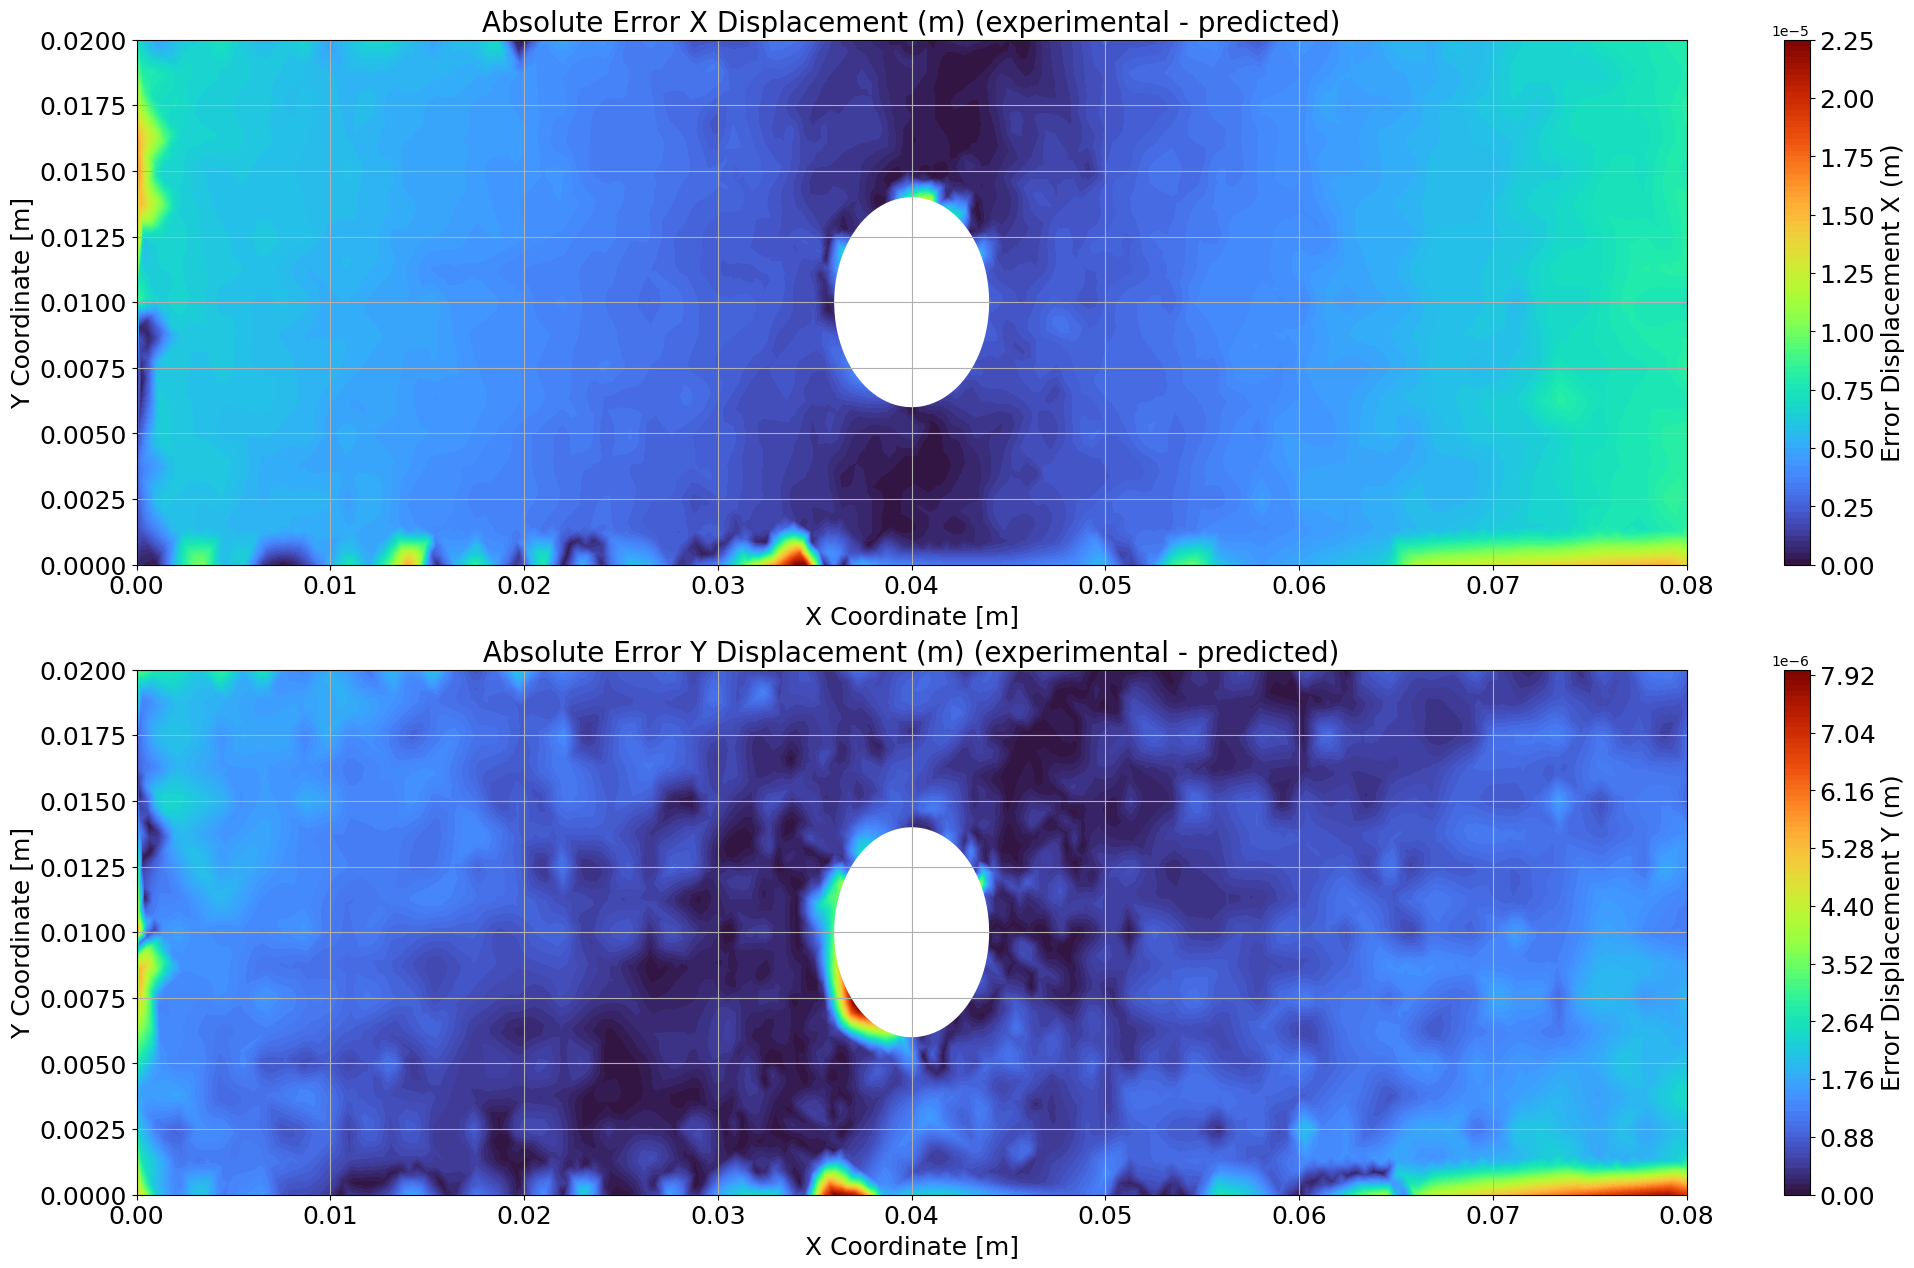

In [143]:
# Compute errors
error_ux_exp = np.abs(ux_exp_interp - ux_approx)
error_uy_exp = np.abs(uy_exp_interp - uy_approx)

print(f"Mean Ux error: {np.mean(error_ux_exp)}")
print(f"Mean Uy error: {np.mean(error_uy_exp)}")

# Plotting the mesh
fig, ax = plt.subplots(2, 1, figsize=(25, 15))
# Subplot for displacement_x
contour_x = ax[0].tricontourf(fem_x.flatten(), fem_y.flatten() , error_ux_exp, levels=100, cmap='turbo')
cbar_x = fig.colorbar(contour_x, ax=ax[0])
cbar_x.set_label(label='Error Displacement X (m)', size='18')
cbar_x.ax.tick_params(labelsize=18)
ax[0].set_title('Absolute Error X Displacement (m) (experimental - predicted)',size='20')
ax[0].set_xlabel('X Coordinate [m]',size='18')
ax[0].set_ylabel('Y Coordinate [m]', size='18')
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].grid(True)

# Adding the hole to the geometry
center_x, center_y = 40e-3, 10e-3
radius = 4e-3


theta = np.linspace(0,2*np.pi,100)
circle_x = center_x + radius * np.cos(theta)
circle_y = center_y + radius * np.sin(theta)
ax[0].fill(circle_x,circle_y,'w-',lw=2)


# Subplot for Y displacement
contour_y = ax[1].tricontourf(fem_x.flatten(), fem_y.flatten() , error_uy_exp, levels=100, cmap='turbo')
cbar_y = fig.colorbar(contour_y, ax=ax[1])
cbar_y.set_label(label='Error Displacement Y (m)', size='18')
cbar_y.ax.tick_params(labelsize=18)
ax[1].set_title('Absolute Error Y Displacement (m) (experimental - predicted)', size='20')
ax[1].set_xlabel('X Coordinate [m]', size='18')
ax[1].set_ylabel('Y Coordinate [m]', size='18')
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].grid(True)
ax[1].fill(circle_x,circle_y,'w-',lw=2)


plt.show()

Plot saved successfully as PDF/FOM_ROM_Error_Displacement_X.pdf


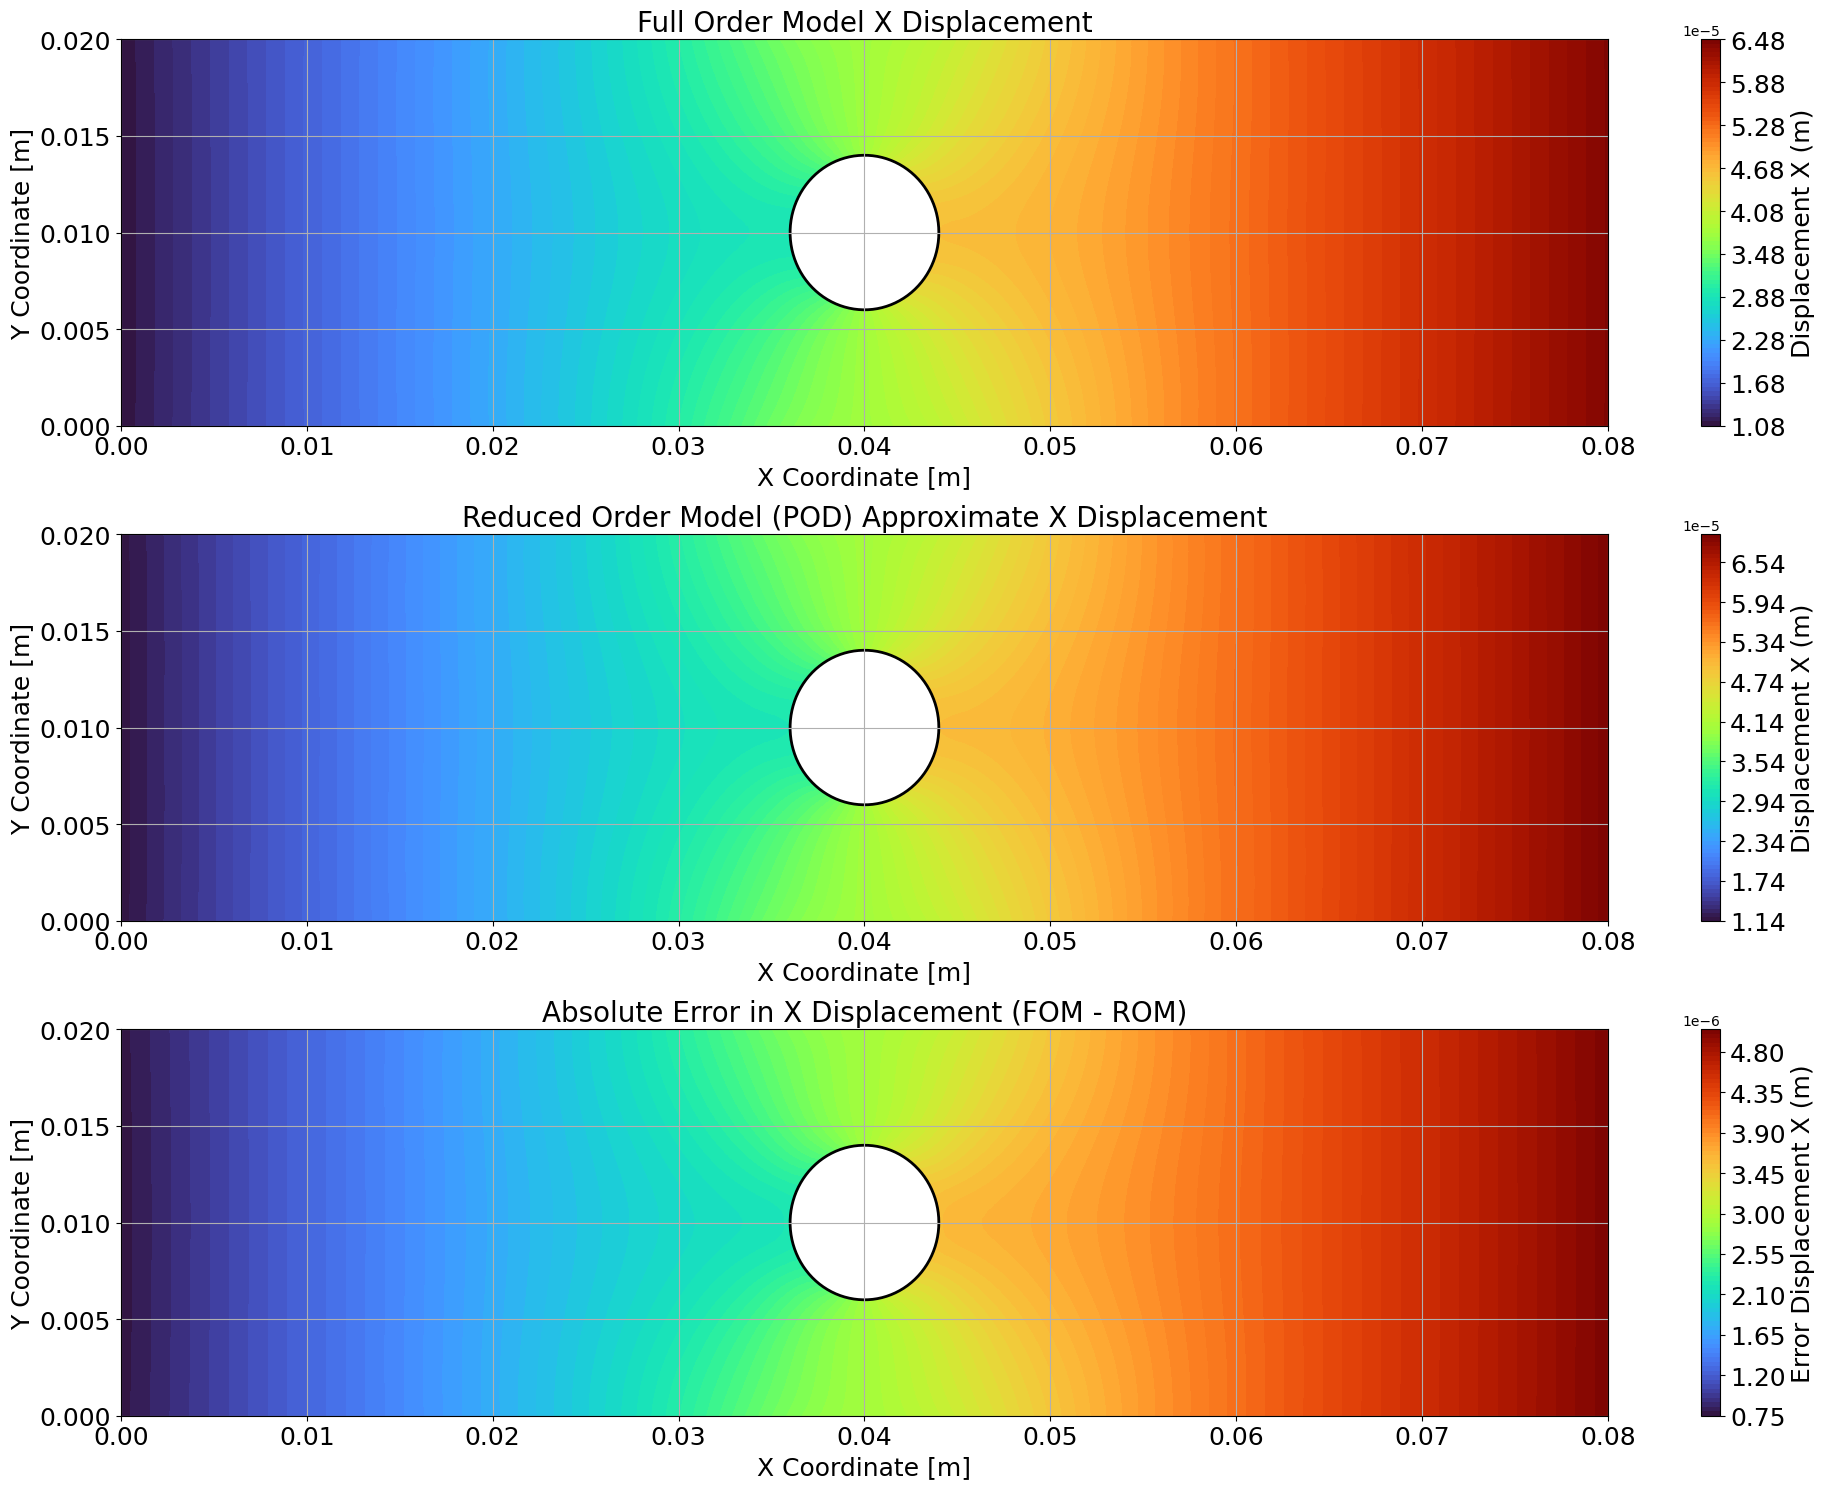

In [ ]:


# Create PDF directory if it doesn't exist
pdf_folder = "PDF"
os.makedirs(pdf_folder, exist_ok=True)

# Define the figure and subplots
fig, ax = plt.subplots(3, 1, figsize=(20, 15))

# --- Subplot 1: Full Order Model X Displacement ---
contour_x = ax[0].tricontourf(fem_x.flatten(), fem_y.flatten(), fem_x_disp, levels=100, cmap='turbo')
cbar_x = fig.colorbar(contour_x, ax=ax[0])
cbar_x.set_label(label='Displacement X (m)', size=18)
cbar_x.ax.tick_params(labelsize=18)
ax[0].set_title('Full Order Model X Displacement', size=20)
ax[0].set_xlabel('X Coordinate [m]', size=18)
ax[0].set_ylabel('Y Coordinate [m]', size=18)
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].grid(True)

# Add hole to geometry
center_x, center_y = 40e-3, 10e-3
radius = 4e-3
theta = np.linspace(0, 2 * np.pi, 100)
circle_x = center_x + radius * np.cos(theta)
circle_y = center_y + radius * np.sin(theta)
ax[0].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 2: Reduced Order Model X Displacement ---
contour_y = ax[1].tricontourf(x.flatten(), y.flatten(), ux_approx, levels=100, cmap='turbo')
cbar_y = fig.colorbar(contour_y, ax=ax[1])
cbar_y.set_label(label='Displacement X (m)', size=18)
cbar_y.ax.tick_params(labelsize=18)
ax[1].set_title('Reduced Order Model (POD) Approximate X Displacement', size=20)
ax[1].set_xlabel('X Coordinate [m]', size=18)
ax[1].set_ylabel('Y Coordinate [m]', size=18)
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].grid(True)
ax[1].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 3: Absolute Error in X Displacement ---
contour_error = ax[2].tricontourf(fem_x.flatten(), fem_y.flatten(), error_ux, levels=100, cmap='turbo')
cbar_error = fig.colorbar(contour_error, ax=ax[2])
cbar_error.set_label(label='Error Displacement X (m)', size=18)
cbar_error.ax.tick_params(labelsize=18)
ax[2].set_title('Absolute Error in X Displacement (FOM - ROM)', size=20)
ax[2].set_xlabel('X Coordinate [m]', size=18)
ax[2].set_ylabel('Y Coordinate [m]', size=18)
ax[2].tick_params(axis='both', which='major', labelsize=18)
ax[2].grid(True)
ax[2].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure as a PDF
pdf_filename = os.path.join(pdf_folder, "FOM_ROM_Error_Displacement_X.pdf")
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Plot saved successfully as {pdf_filename}")

# Show the plot
plt.show()


Plot saved successfully as PDF/FOM_ROM_Error_Displacement_Y.pdf


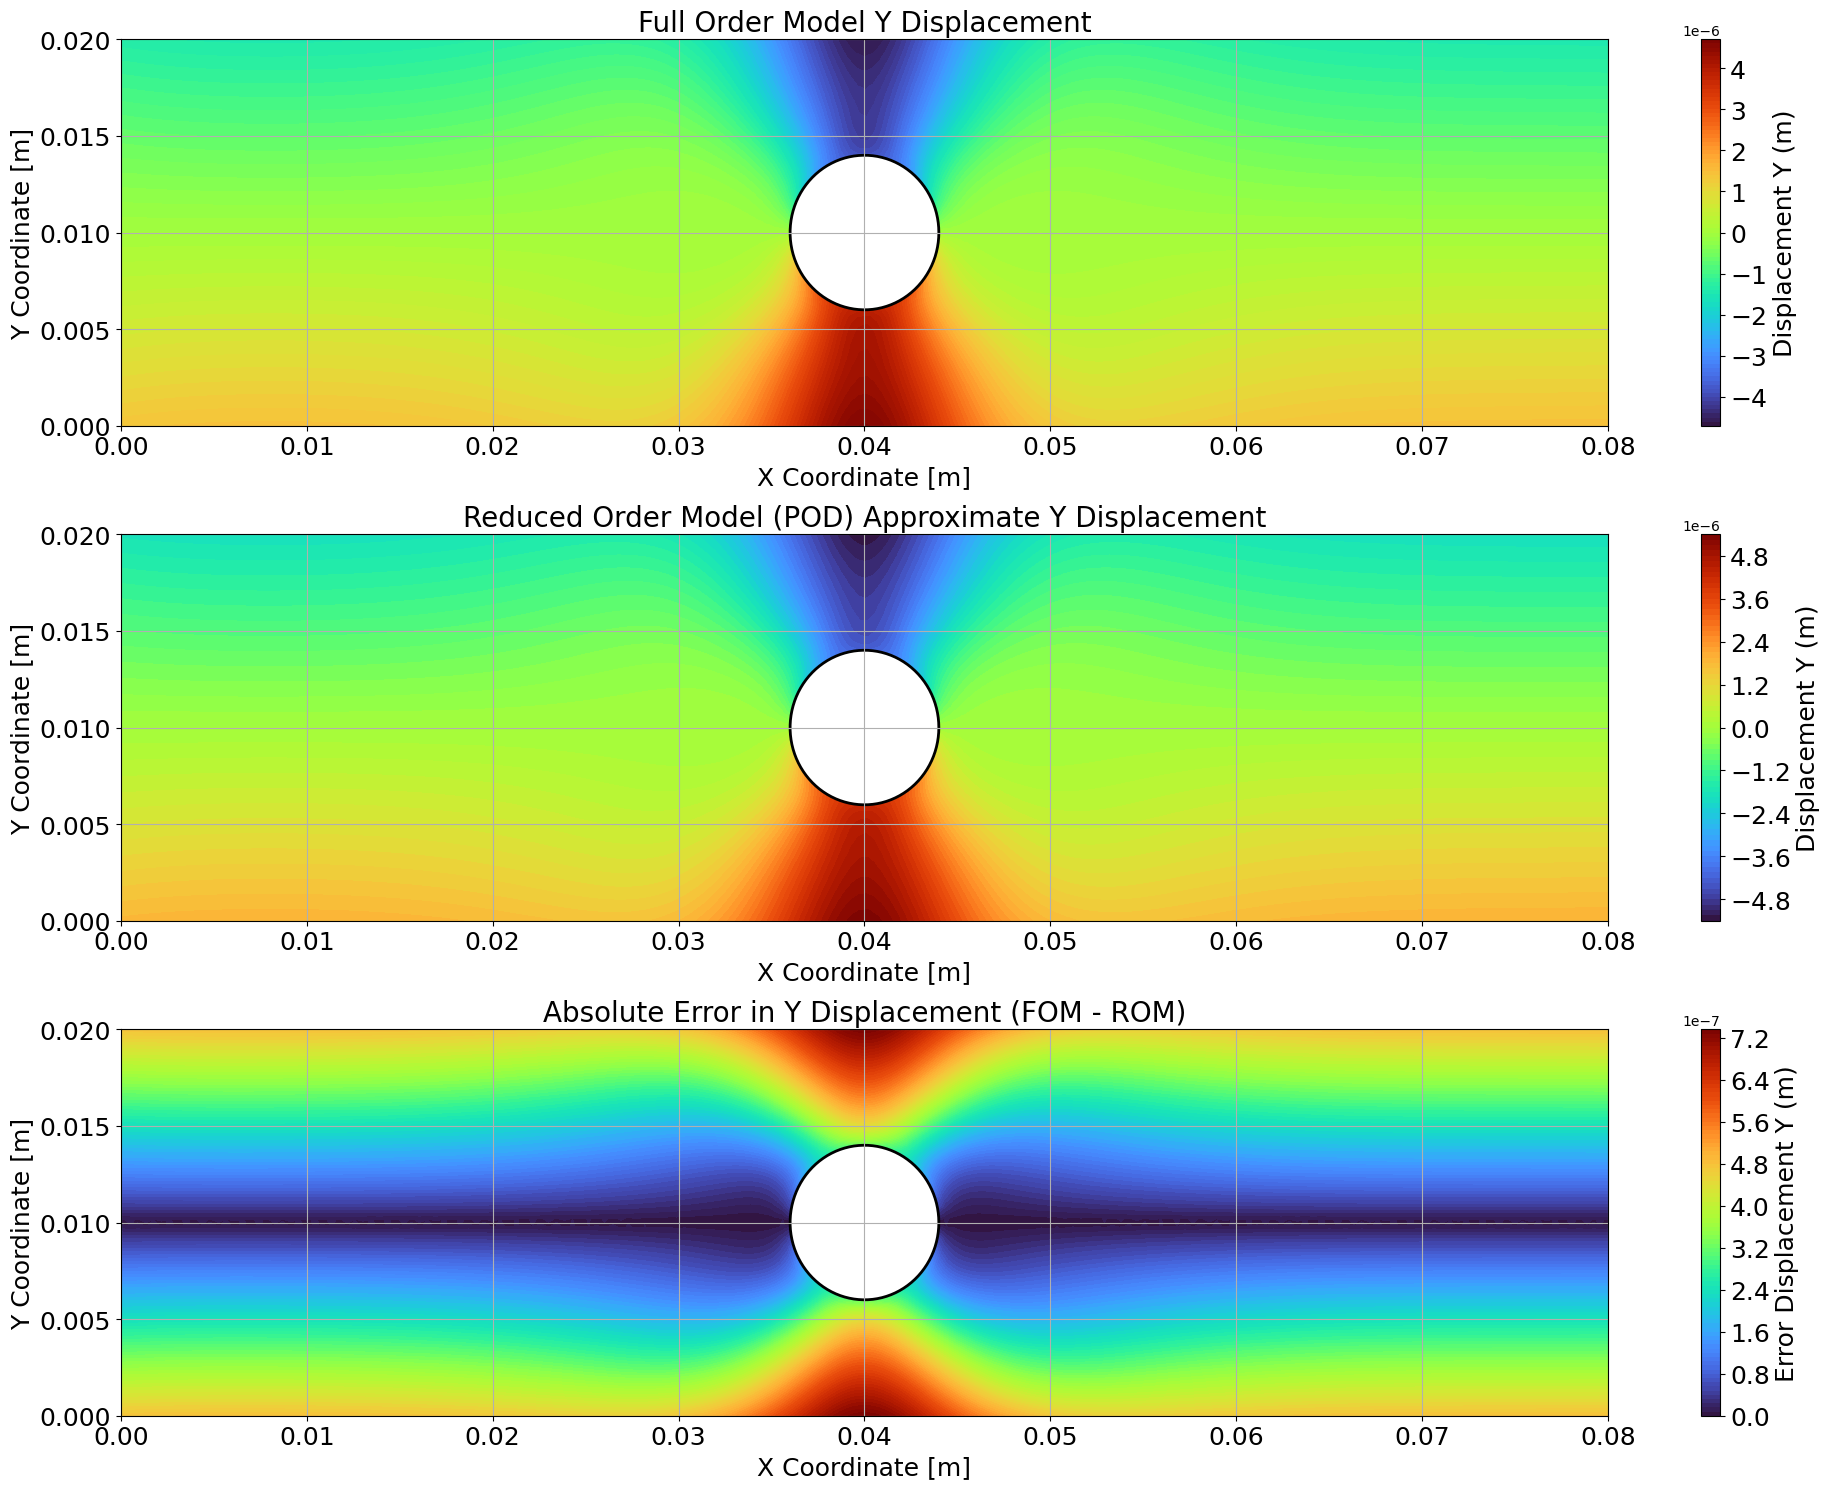

In [ ]:

# Create PDF directory if it doesn't exist
pdf_folder = "PDF"
os.makedirs(pdf_folder, exist_ok=True)

# Define the figure and subplots
fig, ax = plt.subplots(3, 1, figsize=(20, 15))

# --- Subplot 1: Full Order Model X Displacement ---
contour_x = ax[0].tricontourf(fem_x.flatten(), fem_y.flatten(), fem_y_disp, levels=100, cmap='turbo')
cbar_x = fig.colorbar(contour_x, ax=ax[0])
cbar_x.set_label(label='Displacement Y (m)', size=18)
cbar_x.ax.tick_params(labelsize=18)
ax[0].set_title('Full Order Model Y Displacement', size=20)
ax[0].set_xlabel('X Coordinate [m]', size=18)
ax[0].set_ylabel('Y Coordinate [m]', size=18)
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].grid(True)

# Add hole to geometry
center_x, center_y = 40e-3, 10e-3
radius = 4e-3
theta = np.linspace(0, 2 * np.pi, 100)
circle_x = center_x + radius * np.cos(theta)
circle_y = center_y + radius * np.sin(theta)
ax[0].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 2: Reduced Order Model X Displacement ---
contour_y = ax[1].tricontourf(x.flatten(), y.flatten(), uy_approx, levels=100, cmap='turbo')
cbar_y = fig.colorbar(contour_y, ax=ax[1])
cbar_y.set_label(label='Displacement Y (m)', size=18)
cbar_y.ax.tick_params(labelsize=18)
ax[1].set_title('Reduced Order Model (POD) Approximate Y Displacement', size=20)
ax[1].set_xlabel('X Coordinate [m]', size=18)
ax[1].set_ylabel('Y Coordinate [m]', size=18)
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].grid(True)
ax[1].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 3: Absolute Error in X Displacement ---
contour_error = ax[2].tricontourf(fem_x.flatten(), fem_y.flatten(), error_uy, levels=100, cmap='turbo')
cbar_error = fig.colorbar(contour_error, ax=ax[2])
cbar_error.set_label(label='Error Displacement Y (m)', size=18)
cbar_error.ax.tick_params(labelsize=18)
ax[2].set_title('Absolute Error in Y Displacement (FOM - ROM)', size=20)
ax[2].set_xlabel('X Coordinate [m]', size=18)
ax[2].set_ylabel('Y Coordinate [m]', size=18)
ax[2].tick_params(axis='both', which='major', labelsize=18)
ax[2].grid(True)
ax[2].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure as a PDF
pdf_filename = os.path.join(pdf_folder, "FOM_ROM_Error_Displacement_Y.pdf")
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Plot saved successfully as {pdf_filename}")

# Show the plot
plt.show()


Plot saved successfully as PDF/EXP_ROM_Error_Displacement_X.pdf


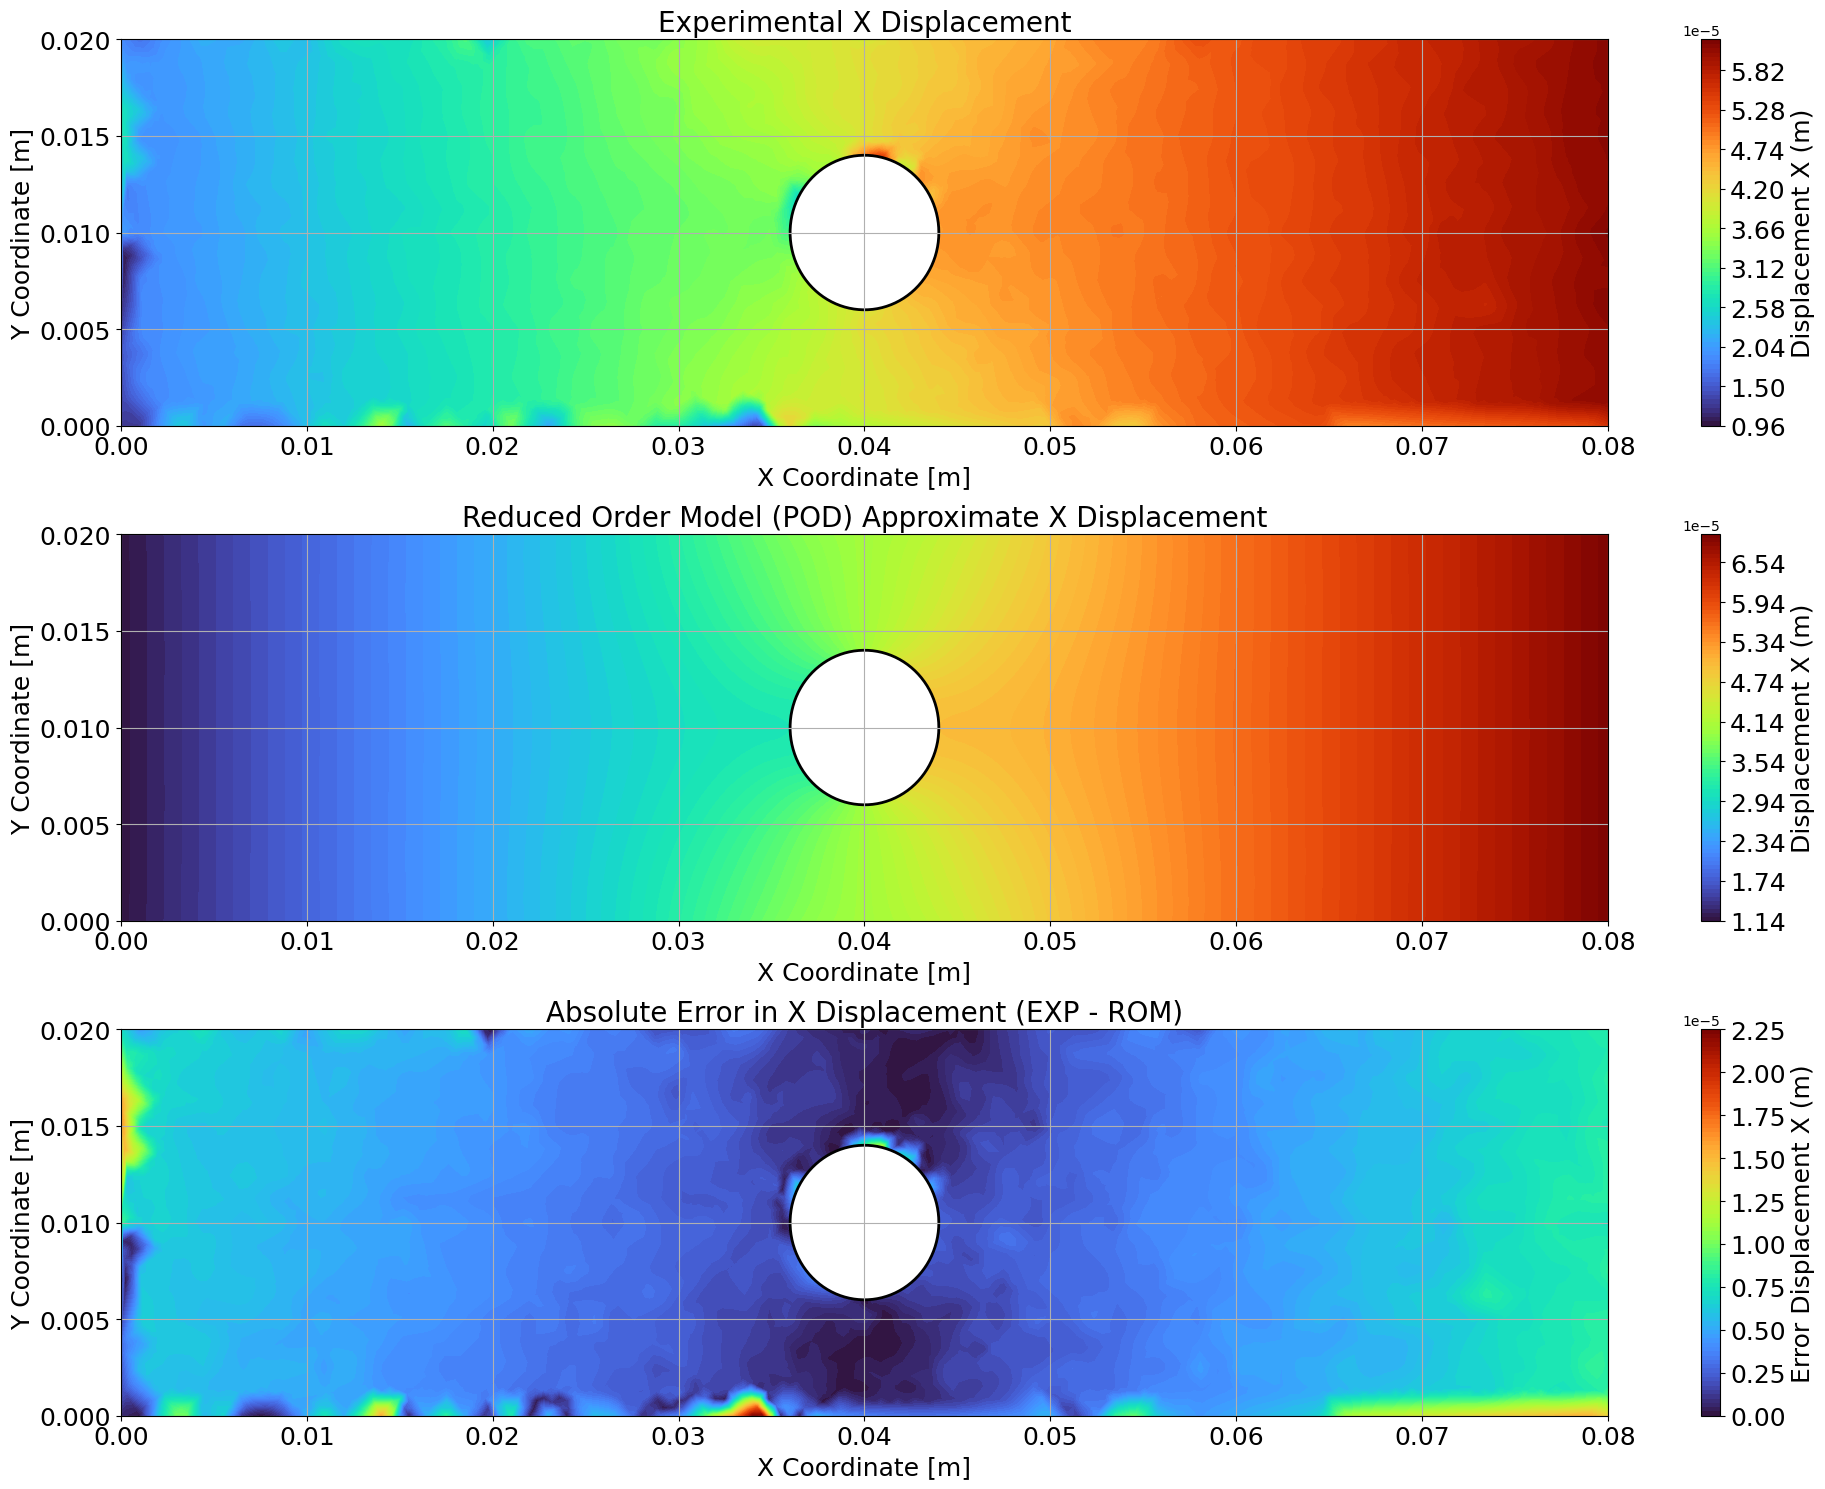

In [ ]:

# Create PDF directory if it doesn't exist
pdf_folder = "PDF"
os.makedirs(pdf_folder, exist_ok=True)

# Define the figure and subplots
fig, ax = plt.subplots(3, 1, figsize=(20, 15))

# --- Subplot 1: Full Order Model X Displacement ---
contour_x = ax[0].tricontourf(fem_x.flatten(), fem_y.flatten(), ux_exp_interp, levels=100, cmap='turbo')
cbar_x = fig.colorbar(contour_x, ax=ax[0])
cbar_x.set_label(label='Displacement X (m)', size=18)
cbar_x.ax.tick_params(labelsize=18)
ax[0].set_title('Experimental X Displacement', size=20)
ax[0].set_xlabel('X Coordinate [m]', size=18)
ax[0].set_ylabel('Y Coordinate [m]', size=18)
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].grid(True)

# Add hole to geometry
center_x, center_y = 40e-3, 10e-3
radius = 4e-3
theta = np.linspace(0, 2 * np.pi, 100)
circle_x = center_x + radius * np.cos(theta)
circle_y = center_y + radius * np.sin(theta)
ax[0].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 2: Reduced Order Model X Displacement ---
contour_y = ax[1].tricontourf(x.flatten(), y.flatten(), ux_approx, levels=100, cmap='turbo')
cbar_y = fig.colorbar(contour_y, ax=ax[1])
cbar_y.set_label(label='Displacement X (m)', size=18)
cbar_y.ax.tick_params(labelsize=18)
ax[1].set_title('Reduced Order Model (POD) Approximate X Displacement', size=20)
ax[1].set_xlabel('X Coordinate [m]', size=18)
ax[1].set_ylabel('Y Coordinate [m]', size=18)
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].grid(True)
ax[1].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 3: Absolute Error in X Displacement ---
contour_error = ax[2].tricontourf(fem_x.flatten(), fem_y.flatten(), error_ux_exp, levels=100, cmap='turbo')
cbar_error = fig.colorbar(contour_error, ax=ax[2])
cbar_error.set_label(label='Error Displacement X (m)', size=18)
cbar_error.ax.tick_params(labelsize=18)
ax[2].set_title('Absolute Error in X Displacement (EXP - ROM)', size=20)
ax[2].set_xlabel('X Coordinate [m]', size=18)
ax[2].set_ylabel('Y Coordinate [m]', size=18)
ax[2].tick_params(axis='both', which='major', labelsize=18)
ax[2].grid(True)
ax[2].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure as a PDF
pdf_filename = os.path.join(pdf_folder, "EXP_ROM_Error_Displacement_X.pdf")
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Plot saved successfully as {pdf_filename}")

# Show the plot
plt.show()


Plot saved successfully as PDF/EXP_ROM_Error_Displacement_Y.pdf


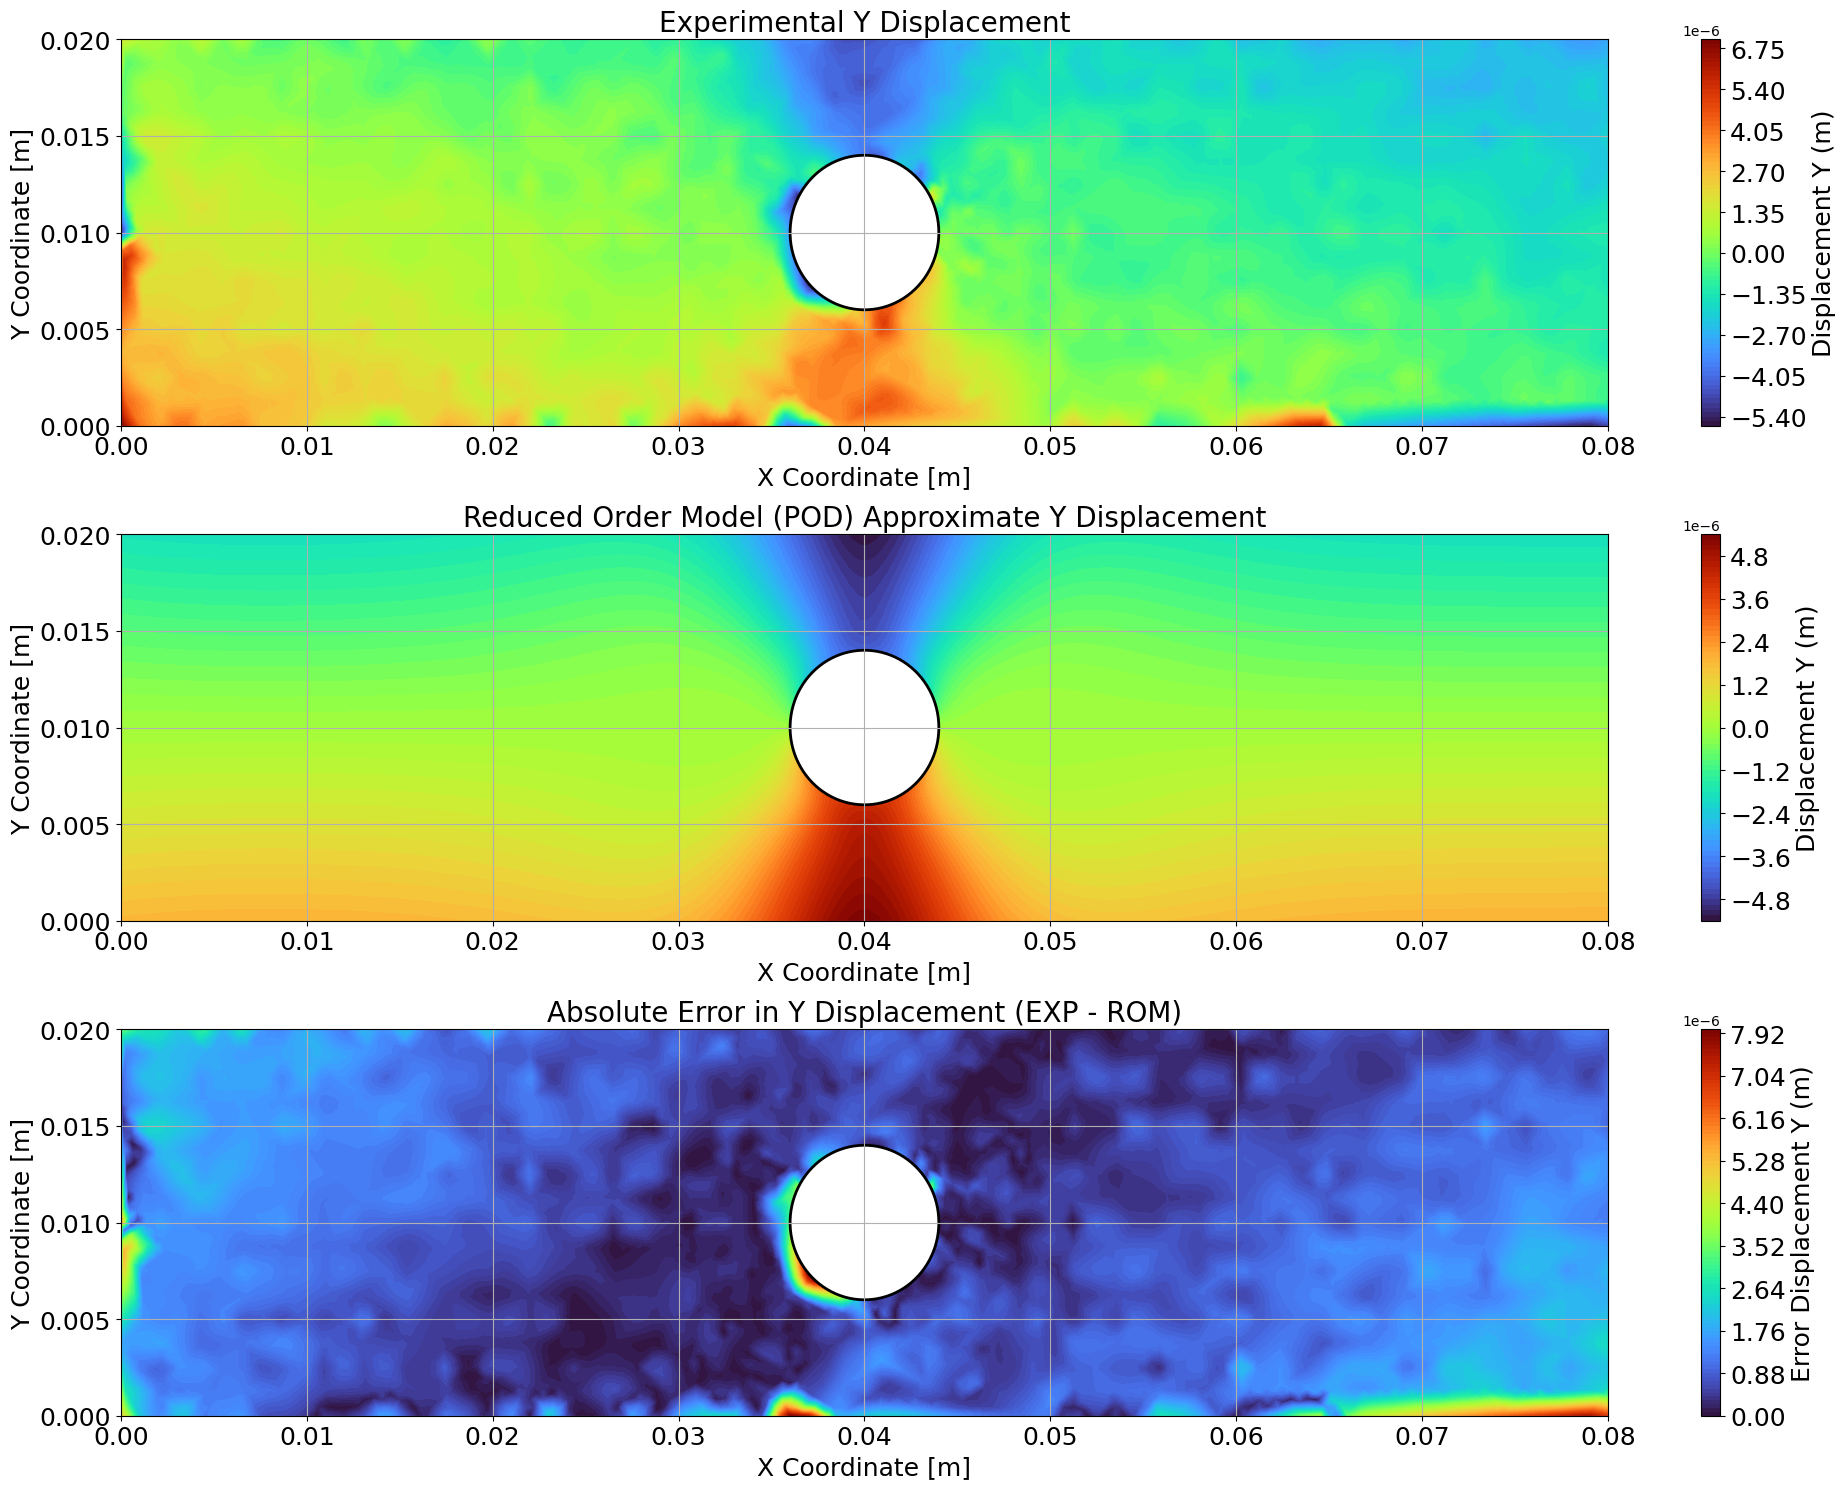

In [ ]:


# Create PDF directory if it doesn't exist
pdf_folder = "PDF"
os.makedirs(pdf_folder, exist_ok=True)

# Define the figure and subplots
fig, ax = plt.subplots(3, 1, figsize=(20, 15))

# --- Subplot 1: Full Order Model X Displacement ---
contour_x = ax[0].tricontourf(fem_x.flatten(), fem_y.flatten(), uy_exp_interp, levels=100, cmap='turbo')
cbar_x = fig.colorbar(contour_x, ax=ax[0])
cbar_x.set_label(label='Displacement Y (m)', size=18)
cbar_x.ax.tick_params(labelsize=18)
ax[0].set_title('Experimental Y Displacement', size=20)
ax[0].set_xlabel('X Coordinate [m]', size=18)
ax[0].set_ylabel('Y Coordinate [m]', size=18)
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].grid(True)

# Add hole to geometry
center_x, center_y = 40e-3, 10e-3
radius = 4e-3
theta = np.linspace(0, 2 * np.pi, 100)
circle_x = center_x + radius * np.cos(theta)
circle_y = center_y + radius * np.sin(theta)
ax[0].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 2: Reduced Order Model X Displacement ---
contour_y = ax[1].tricontourf(x.flatten(), y.flatten(), uy_approx, levels=100, cmap='turbo')
cbar_y = fig.colorbar(contour_y, ax=ax[1])
cbar_y.set_label(label='Displacement Y (m)', size=18)
cbar_y.ax.tick_params(labelsize=18)
ax[1].set_title('Reduced Order Model (POD) Approximate Y Displacement', size=20)
ax[1].set_xlabel('X Coordinate [m]', size=18)
ax[1].set_ylabel('Y Coordinate [m]', size=18)
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].grid(True)
ax[1].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 3: Absolute Error in X Displacement ---
contour_error = ax[2].tricontourf(fem_x.flatten(), fem_y.flatten(), error_uy_exp, levels=100, cmap='turbo')
cbar_error = fig.colorbar(contour_error, ax=ax[2])
cbar_error.set_label(label='Error Displacement Y (m)', size=18)
cbar_error.ax.tick_params(labelsize=18)
ax[2].set_title('Absolute Error in Y Displacement (EXP - ROM)', size=20)
ax[2].set_xlabel('X Coordinate [m]', size=18)
ax[2].set_ylabel('Y Coordinate [m]', size=18)
ax[2].tick_params(axis='both', which='major', labelsize=18)
ax[2].grid(True)
ax[2].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure as a PDF
pdf_filename = os.path.join(pdf_folder, "EXP_ROM_Error_Displacement_Y.pdf")
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Plot saved successfully as {pdf_filename}")

# Show the plot
plt.show()


Plot saved successfully as PDF/EXP_FOM_Error_Displacement_X.pdf


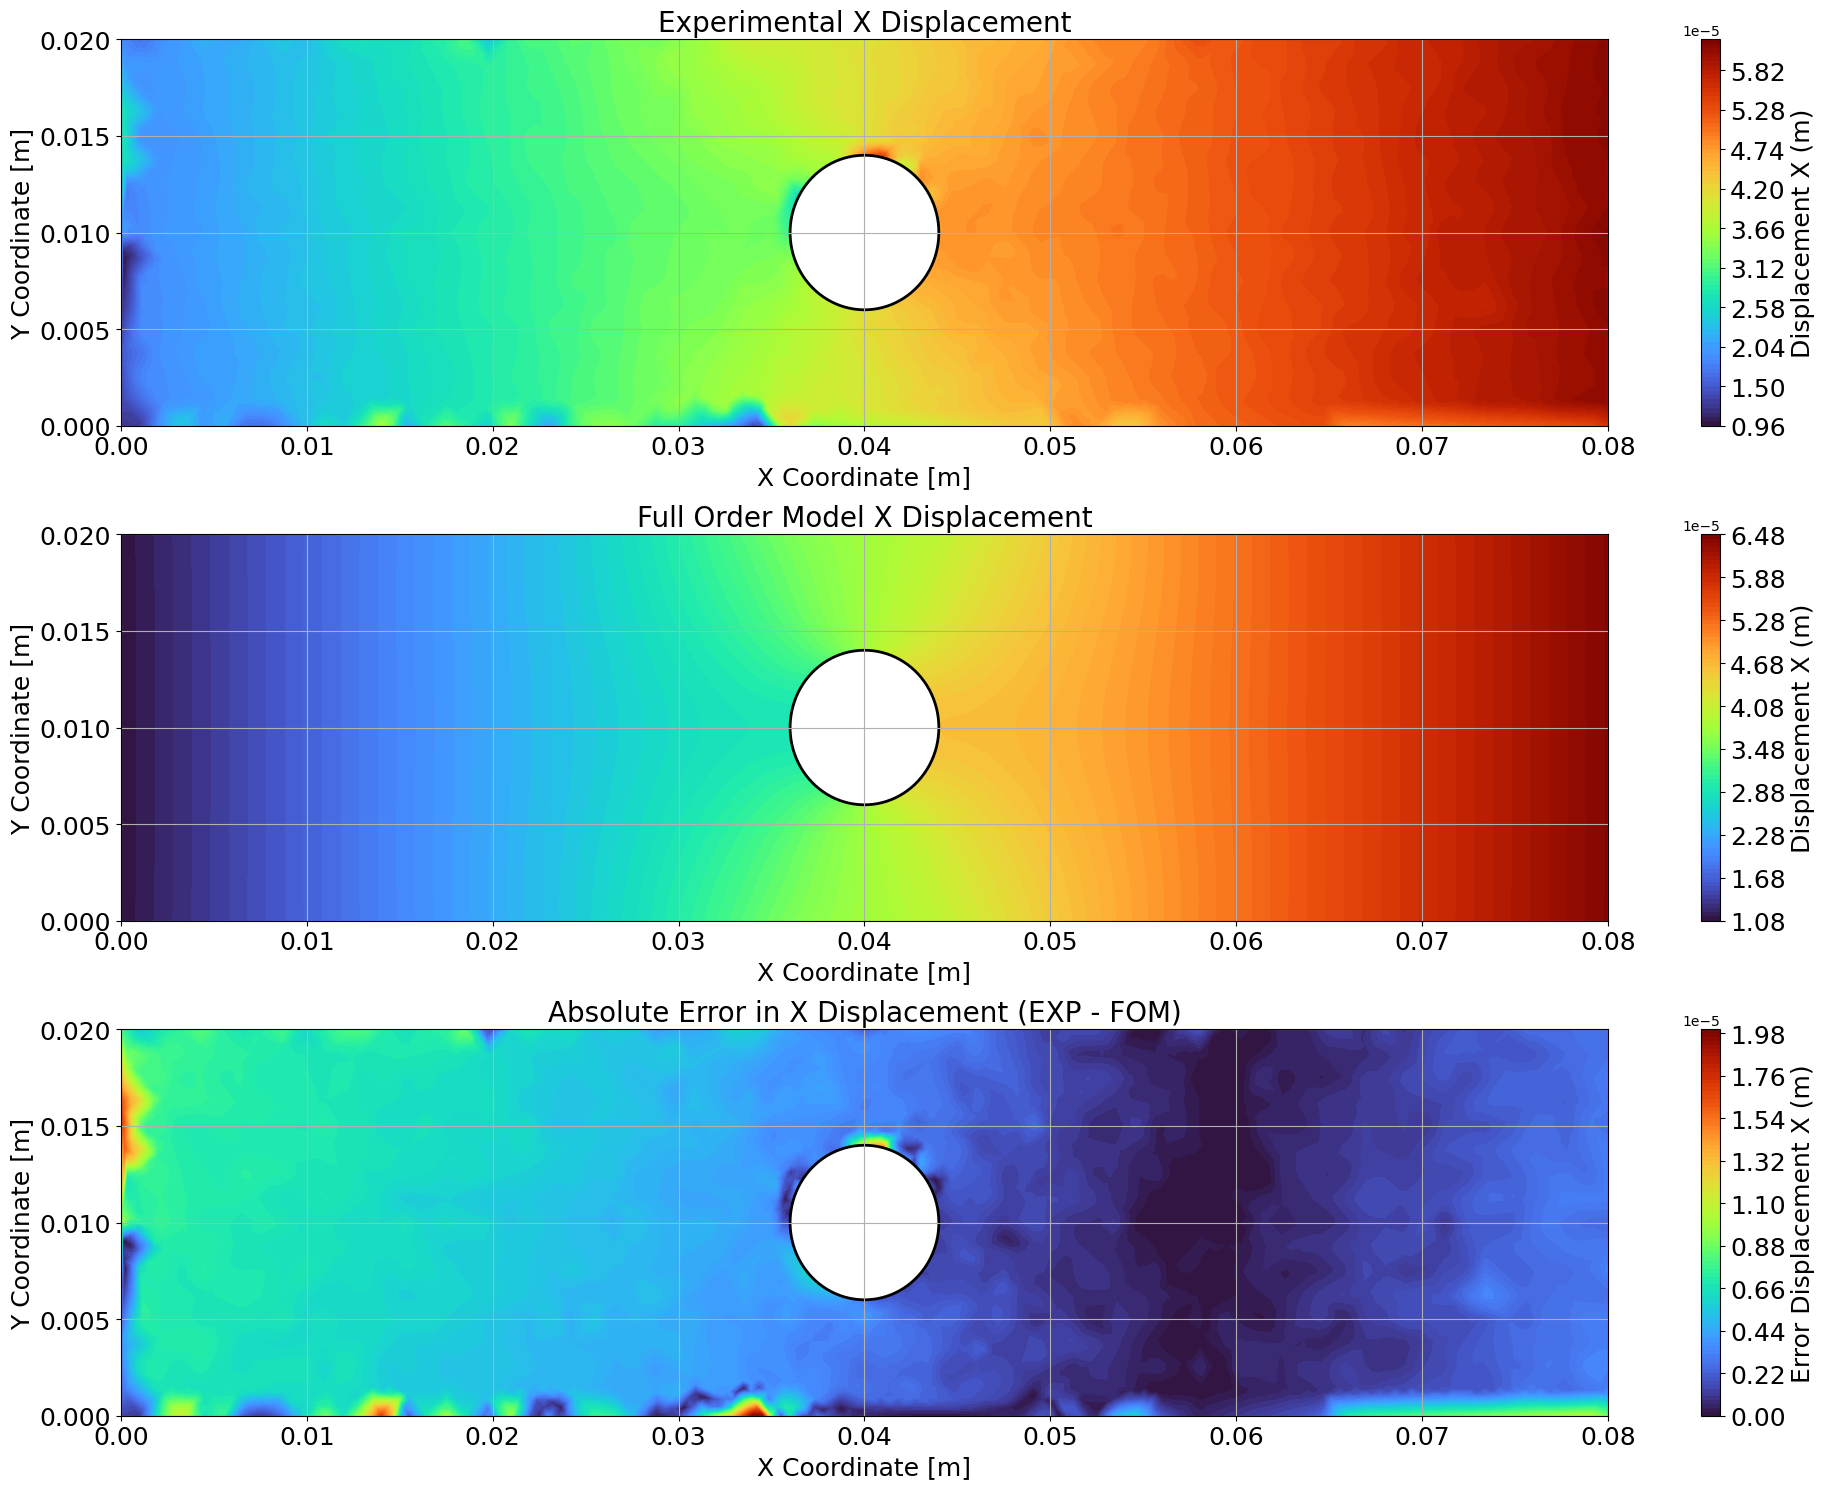

In [ ]:


# Define the figure and subplots
fig, ax = plt.subplots(3, 1, figsize=(20, 15))

# --- Subplot 1: Full Order Model X Displacement ---
contour_x = ax[0].tricontourf(fem_x.flatten(), fem_y.flatten(), ux_exp_interp, levels=100, cmap='turbo')
cbar_x = fig.colorbar(contour_x, ax=ax[0])
cbar_x.set_label(label='Displacement X (m)', size=18)
cbar_x.ax.tick_params(labelsize=18)
ax[0].set_title('Experimental X Displacement', size=20)
ax[0].set_xlabel('X Coordinate [m]', size=18)
ax[0].set_ylabel('Y Coordinate [m]', size=18)
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].grid(True)

# Add hole to geometry
center_x, center_y = 40e-3, 10e-3
radius = 4e-3
theta = np.linspace(0, 2 * np.pi, 100)
circle_x = center_x + radius * np.cos(theta)
circle_y = center_y + radius * np.sin(theta)
ax[0].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 2: Reduced Order Model X Displacement ---
contour_y = ax[1].tricontourf(x.flatten(), y.flatten(), fem_x_disp, levels=100, cmap='turbo')
cbar_y = fig.colorbar(contour_y, ax=ax[1])
cbar_y.set_label(label='Displacement X (m)', size=18)
cbar_y.ax.tick_params(labelsize=18)
ax[1].set_title('Full Order Model X Displacement', size=20)
ax[1].set_xlabel('X Coordinate [m]', size=18)
ax[1].set_ylabel('Y Coordinate [m]', size=18)
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].grid(True)
ax[1].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 3: Absolute Error in X Displacement ---
contour_error = ax[2].tricontourf(fem_x.flatten(), fem_y.flatten(), error_ux_fom_exp, levels=100, cmap='turbo')
cbar_error = fig.colorbar(contour_error, ax=ax[2])
cbar_error.set_label(label='Error Displacement X (m)', size=18)
cbar_error.ax.tick_params(labelsize=18)
ax[2].set_title('Absolute Error in X Displacement (EXP - FOM)', size=20)
ax[2].set_xlabel('X Coordinate [m]', size=18)
ax[2].set_ylabel('Y Coordinate [m]', size=18)
ax[2].tick_params(axis='both', which='major', labelsize=18)
ax[2].grid(True)
ax[2].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure as a PDF
pdf_filename = os.path.join(pdf_folder, "EXP_FOM_Error_Displacement_X.pdf")
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Plot saved successfully as {pdf_filename}")

# Show the plot
plt.show()


Plot saved successfully as PDF/EXP_FOM_Error_Displacement_Y.pdf


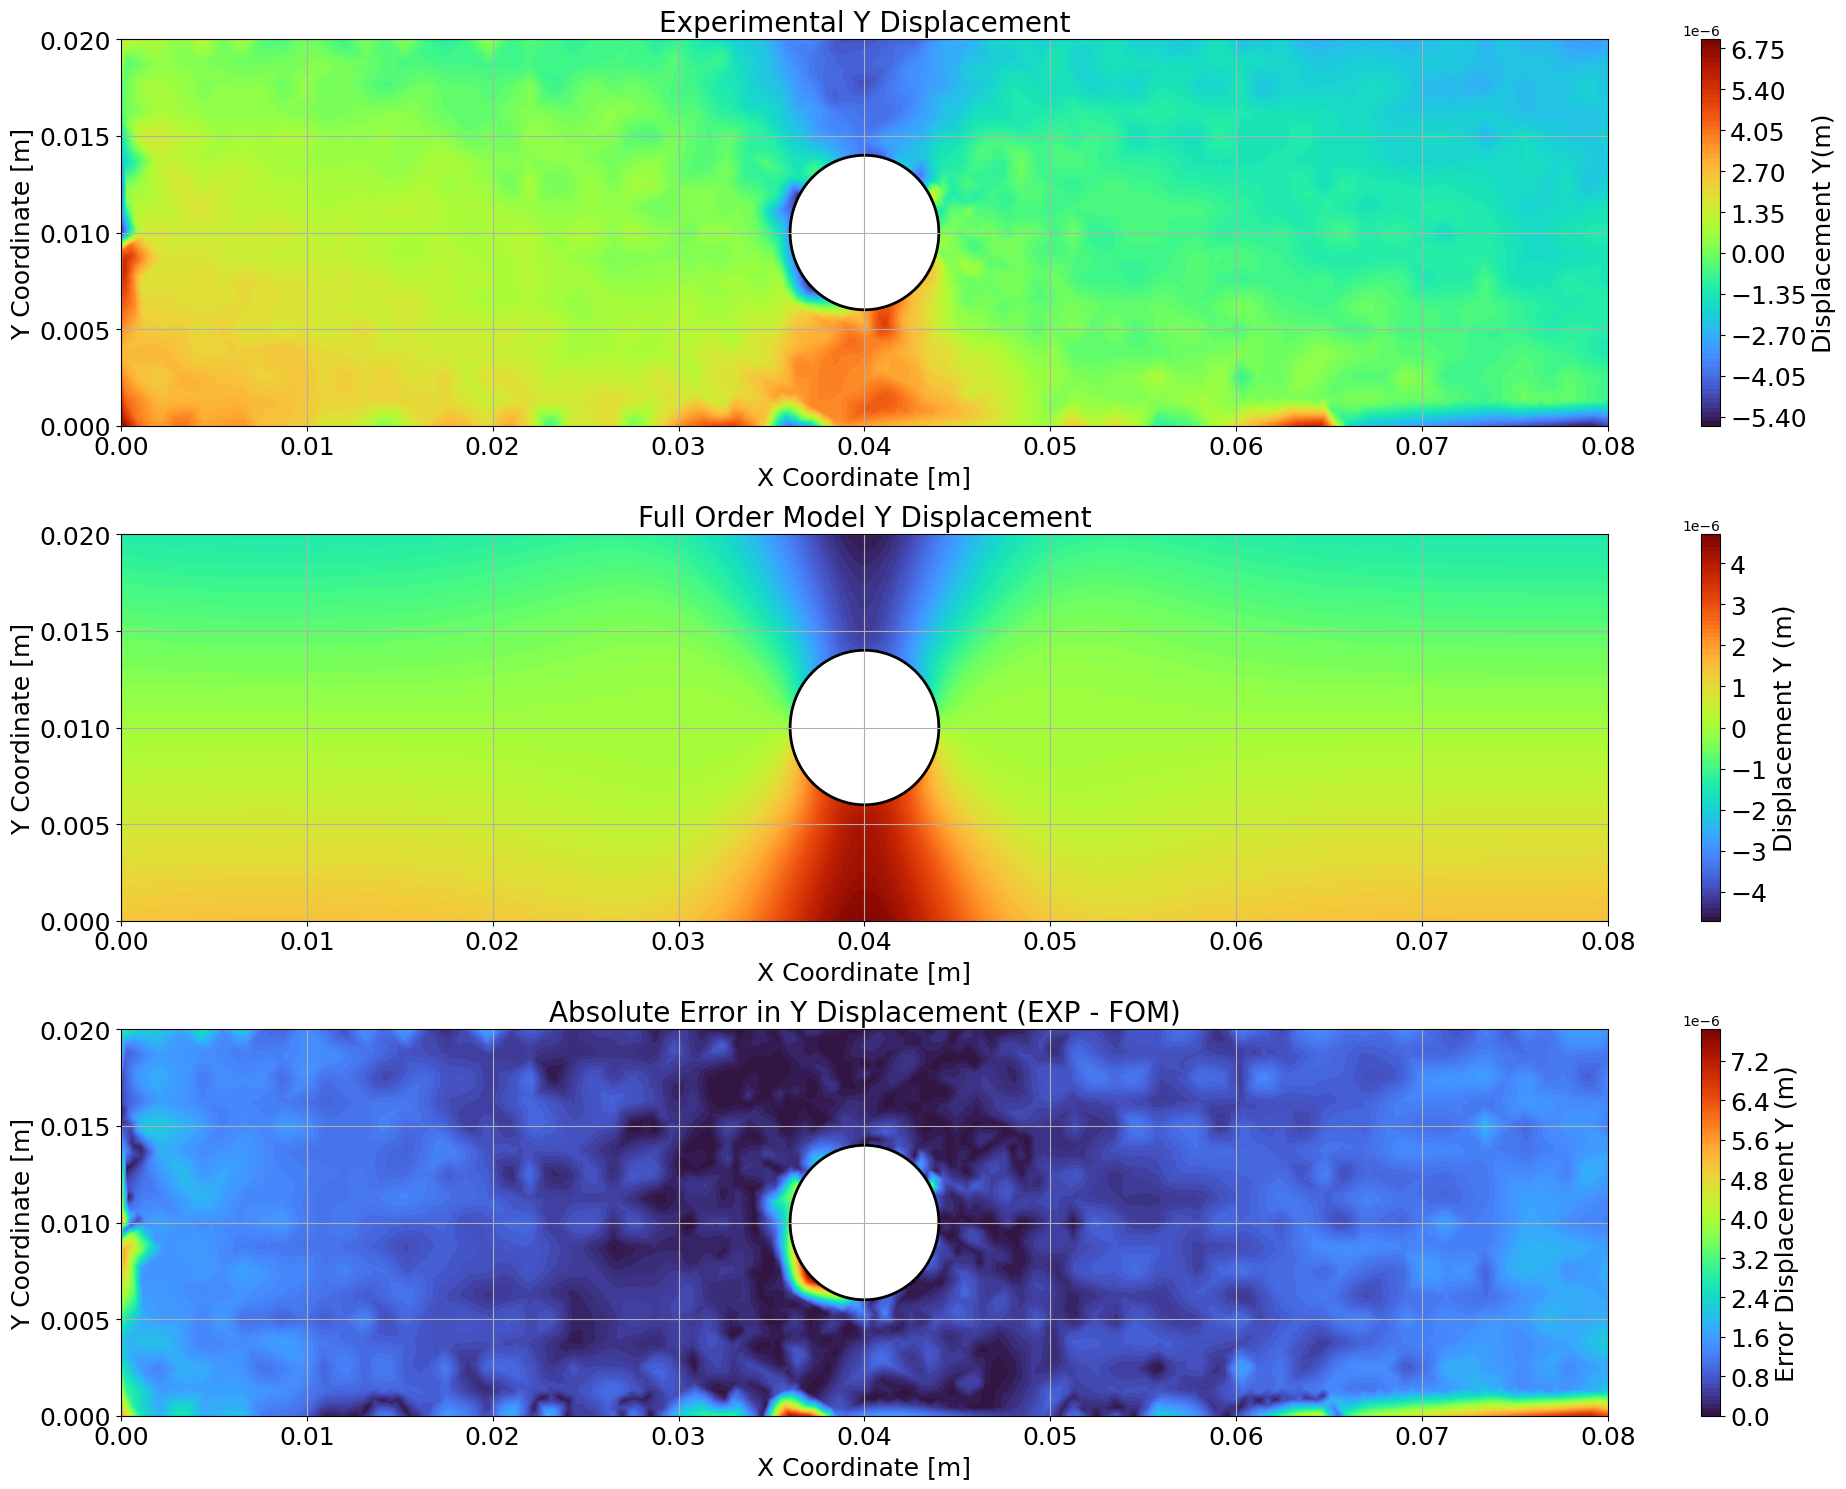

In [ ]:

# Define the figure and subplots
fig, ax = plt.subplots(3, 1, figsize=(20, 15))

# --- Subplot 1: Full Order Model X Displacement ---
contour_x = ax[0].tricontourf(fem_x.flatten(), fem_y.flatten(), uy_exp_interp, levels=100, cmap='turbo')
cbar_x = fig.colorbar(contour_x, ax=ax[0])
cbar_x.set_label(label='Displacement Y(m)', size=18)
cbar_x.ax.tick_params(labelsize=18)
ax[0].set_title('Experimental Y Displacement', size=20)
ax[0].set_xlabel('X Coordinate [m]', size=18)
ax[0].set_ylabel('Y Coordinate [m]', size=18)
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].grid(True)

# Add hole to geometry
center_x, center_y = 40e-3, 10e-3
radius = 4e-3
theta = np.linspace(0, 2 * np.pi, 100)
circle_x = center_x + radius * np.cos(theta)
circle_y = center_y + radius * np.sin(theta)
ax[0].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 2: Reduced Order Model X Displacement ---
contour_y = ax[1].tricontourf(x.flatten(), y.flatten(), fem_y_disp, levels=100, cmap='turbo')
cbar_y = fig.colorbar(contour_y, ax=ax[1])
cbar_y.set_label(label='Displacement Y (m)', size=18)
cbar_y.ax.tick_params(labelsize=18)
ax[1].set_title('Full Order Model Y Displacement', size=20)
ax[1].set_xlabel('X Coordinate [m]', size=18)
ax[1].set_ylabel('Y Coordinate [m]', size=18)
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].grid(True)
ax[1].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# --- Subplot 3: Absolute Error in X Displacement ---
contour_error = ax[2].tricontourf(fem_x.flatten(), fem_y.flatten(), error_uy_fom_exp, levels=100, cmap='turbo')
cbar_error = fig.colorbar(contour_error, ax=ax[2])
cbar_error.set_label(label='Error Displacement Y (m)', size=18)
cbar_error.ax.tick_params(labelsize=18)
ax[2].set_title('Absolute Error in Y Displacement (EXP - FOM)', size=20)
ax[2].set_xlabel('X Coordinate [m]', size=18)
ax[2].set_ylabel('Y Coordinate [m]', size=18)
ax[2].tick_params(axis='both', which='major', labelsize=18)
ax[2].grid(True)
ax[2].fill(circle_x, circle_y, 'w', edgecolor='k', lw=2)

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure as a PDF
pdf_filename = os.path.join(pdf_folder, "EXP_FOM_Error_Displacement_Y.pdf")
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Plot saved successfully as {pdf_filename}")

# Show the plot
plt.show()
